In [0]:
%python

# Customer Churn Prediction — Retail Transaction Data
# Module: BUSI4373 · MSc Business Analytics  
# Dataset: FoodCorp retail loyalty data (`ml34`)


import urllib
db_type = 'ml'
data_id = 34
exec(urllib.request.urlopen('https://drive.google.com/uc?export=download&id=151MlxWk3Nk-Q3emLDyOFRxPA8lCqgGt-').read())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 19.3 MB/s eta 0:00:00
Initaializing ml34 database.... on first run this will take a couple of minutes.
Done.
You can find your individual report in Catalog -> workspace ->  default -> Volumes -> cw -> ml
All tables from your dataset as listed below. Tables are linked with one-to-many relationships when the field names are the same. Use the SQL:
SHOW TABLES
to list all tables, including those you have generated.
┏━━━━━━━━━━━━━┓
┃ customers   ┃
┣━━━━━━━━━━━━━┫
┃ customer_id ┃
┃ first       ┃
┃ last        ┃
┃ dob         ┃
┗━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━━━━━━━━━┓
┃ products             ┃
┣━━━━━━━━━━━━━━━━━━━━━━┫
┃ product_code         ┃
┃ product_details      ┃
┃ department_code      ┃
┃ department_name      ┃
┃ category_code        ┃
┃ category_details     ┃
┃ sub_category_code    ┃
┃ sub_category_details ┃
┗━━━━━━━━━━━━━━━━━━━━━━┛
┏━━━━━━━━━━━━━━━━━┓
┃

In [0]:
%sql
SHOW TABLES IN workspace.ml34

database,tableName,isTemporary
ml34,customers,false
ml34,features_r300,false
ml34,features_r400,false
ml34,features_r500,false
ml34,labels_r300,false
ml34,labels_r400,false
ml34,labels_r500,false
ml34,products,false
ml34,receipt_lines,false
ml34,receipts,false


## Schema Inspection

In [0]:
%python

# Looping through all five tables and print their column definitions
tables = ["customers", "products", "receipt_lines", "receipts", "stores"]

for i in tables:
    print(f"\n{'='*60}")
    print(f"  TABLE: ml34.{i}")
    print(f"{'='*60}")
    spark.sql(f"DESCRIBE ml34.{i}").show(truncate=False)


  TABLE: ml34.customers
+-----------+---------+-------+
|col_name   |data_type|comment|
+-----------+---------+-------+
|customer_id|int      |NULL   |
|first      |string   |NULL   |
|last       |string   |NULL   |
|dob        |date     |NULL   |
+-----------+---------+-------+


  TABLE: ml34.products
+--------------------+---------+-------+
|col_name            |data_type|comment|
+--------------------+---------+-------+
|product_code        |int      |NULL   |
|product_details     |string   |NULL   |
|department_code     |int      |NULL   |
|department_name     |string   |NULL   |
|category_code       |int      |NULL   |
|category_details    |string   |NULL   |
|sub_category_code   |int      |NULL   |
|sub_category_details|string   |NULL   |
+--------------------+---------+-------+


  TABLE: ml34.receipt_lines
+---------------+---------+-------+
|col_name       |data_type|comment|
+---------------+---------+-------+
|receipt_line_id|int      |NULL   |
|receipt_id     |int      |N

## Row Counts & Sanity Check
If `receipt_lines` ≤ `receipts`, something is wrong — either the join keys are off or the tables
are mislabelled. I've flagged this as an explicit sanity check.

customers: 8,526 rows
products: 20,570 rows
receipt_lines: 1,942,995 rows
receipts: 200,780 rows
stores: 4 rows

Sanity check passed.


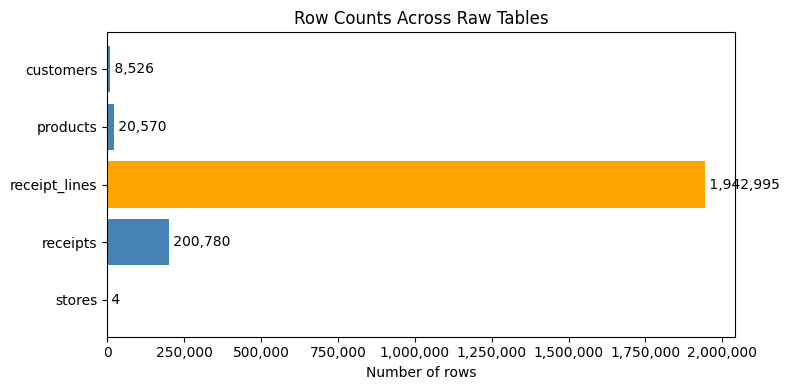

In [0]:
%python

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

tables = ["customers", "products", "receipt_lines", "receipts", "stores"]
counts = {}

for table in tables:
    count = spark.sql(f"SELECT COUNT(*) AS n FROM ml34.{table}").collect()[0]["n"]
    counts[table] = count
    print(f"{table}: {count:,} rows")

# grain sanity check: receipt_lines should always exceed receipts
if counts["receipt_lines"] > counts["receipts"]:
    print("\nSanity check passed.")
else:
    print("\nSanity check failed.")

table_names = list(counts.keys())
table_counts = list(counts.values())

colors = []

for table in table_names:
    if table == "receipt_lines":
        colors.append("orange")
    else:
        colors.append("steelblue")

plt.figure(figsize=(8, 4))
plt.barh(table_names, table_counts, color=colors)
plt.title("Row Counts Across Raw Tables")
plt.xlabel("Number of rows")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.gca().invert_yaxis()

for i, count in enumerate(table_counts):
    plt.text(count, i, f" {count:,}", va="center")
plt.tight_layout()
plt.show()

## Date Range & Referential Integrity
**Two specific checks:**
- Are there `customer_id` values in `receipts` that don't exist in `customers`? (orphan customers)
- Are there `store_code` values in `receipts` that don't exist in `stores`? (orphan stores)


In [0]:
%sql
SELECT MIN(purchased_at) AS earliest_date,
    MAX(purchased_at) AS latest_date,
    DATEDIFF(MAX(purchased_at), MIN(purchased_at)) AS total_days_span,
    COUNT(DISTINCT purchased_at) AS distinct_transaction_days,
    COUNT(DISTINCT customer_id) AS distinct_customers_in_receipts
FROM workspace.ml34.receipts;

earliest_date,latest_date,total_days_span,distinct_transaction_days,distinct_customers_in_receipts
2020-07-22,2022-03-22,608,607,8314


In [0]:
%sql
SELECT COUNT(DISTINCT r.customer_id) AS customers_in_receipts,
    COUNT(DISTINCT c.customer_id) AS customers_in_dim_table,
    COUNT(DISTINCT CASE WHEN c.customer_id IS NULL
                        THEN r.customer_id END) AS orphan_customers
FROM ml34.receipts r
LEFT JOIN ml34.customers c ON r.customer_id = c.customer_id;

customers_in_receipts,customers_in_dim_table,orphan_customers
8314,8314,0


In [0]:
%sql
SELECT COUNT(DISTINCT r.store_code) AS stores_in_receipts,
    COUNT(DISTINCT s.store_code) AS stores_in_dim_table,
    COUNT(DISTINCT CASE WHEN s.store_code IS NULL
                        THEN r.store_code END) AS orphan_store_codes
FROM ml34.receipts r
LEFT JOIN ml34.stores s
    ON r.store_code = s.store_code;

stores_in_receipts,stores_in_dim_table,orphan_store_codes
4,4,0


## Null Checks & Value Distribution
The `value` field (line spend in £) needs careful inspection. I'm looking for:
- **Negative values** — could represent returns/refunds, which are legitimate but need careful handling
- **Zero values** — possibly promotional items or data errors
- **Extreme outliers** — values in the hundreds or thousands could be genuine bulk purchases,
  or they could be sentinel/error codes

In [0]:
%sql
SELECT SUM(CASE WHEN r.customer_id IS NULL THEN 1 ELSE 0 END) AS receipts_null_customer_id,
    SUM(CASE WHEN r.purchased_at IS NULL THEN 1 ELSE 0 END) AS receipts_null_date,
    SUM(CASE WHEN r.store_code IS NULL THEN 1 ELSE 0 END) AS receipts_null_store_code,
    SUM(CASE WHEN rl.value IS NULL THEN 1 ELSE 0 END) AS lines_null_value,
    SUM(CASE WHEN rl.qty IS NULL THEN 1 ELSE 0 END) AS lines_null_qty,
    SUM(CASE WHEN rl.product_code IS NULL THEN 1 ELSE 0 END) AS lines_null_product_code
FROM workspace.ml34.receipts r
LEFT JOIN workspace.ml34.receipt_lines rl ON r.receipt_id = rl.receipt_id;

receipts_null_customer_id,receipts_null_date,receipts_null_store_code,lines_null_value,lines_null_qty,lines_null_product_code
0,0,0,0,0,0


In [0]:
%sql
SELECT COUNT(*) AS total_lines,
    COUNT(CASE WHEN value < 0 THEN 1 END) AS negative_value_lines,
    COUNT(CASE WHEN value = 0 THEN 1 END) AS zero_value_lines,
    ROUND(MIN(value),  2) AS min_value,
    ROUND(MAX(value),  2) AS max_value,
    ROUND(AVG(value),  2) AS avg_value,
    ROUND(AVG(qty),    2) AS avg_qty
FROM ml34.receipt_lines;

total_lines,negative_value_lines,zero_value_lines,min_value,max_value,avg_value,avg_qty
1942995,488,1,-100.0,9999999.0,114.85,1.2


In [0]:
%sql
SELECT receipt_line_id, receipt_id, product_code, qty, value 
    FROM ml34.receipt_lines
    WHERE value > 500
    ORDER BY value DESC
    LIMIT 50;

receipt_line_id,receipt_id,product_code,qty,value
25157,1916,6222,2,9999999.0
28350,169685,4096,1,9999999.0
28356,169685,14583,1,9999999.0
25158,1916,3668,1,9999999.0
11313,210770,6378,1,9999999.0
28349,169685,10471,1,9999999.0
25153,1916,18214,1,9999999.0
25151,1916,3745,1,9999999.0
28352,169685,6905,1,9999999.0
28347,169685,6472,1,9999999.0


In [0]:
%sql
SELECT COUNT(*) AS total_lines,
    SUM(CASE WHEN value < 0 THEN 1 ELSE 0 END) AS negative_value_lines,
    SUM(CASE WHEN value > 500 THEN 1 ELSE 0 END) AS lines_above_500,
    SUM(CASE WHEN value > 1000 THEN 1 ELSE 0 END) AS lines_above_1000,
    -- Checking for sentinel values: 9999999 is a suspiciously round number
    SUM(CASE WHEN value = 9999999 THEN 1 ELSE 0 END) AS exact_9999999_lines,
    ROUND(MIN(value), 2) AS min_value,
    ROUND(MAX(value), 2) AS max_value,
    ROUND(AVG(value), 2) AS avg_value_raw,
    ROUND(AVG(CASE WHEN value <> 9999999 THEN value END), 2) AS avg_value_excluding_9999999
FROM ml34.receipt_lines;

total_lines,negative_value_lines,lines_above_500,lines_above_1000,exact_9999999_lines,min_value,max_value,avg_value_raw,avg_value_excluding_9999999
1942995,488,22,22,22,-100.0,9999999.0,114.85,1.63


## Handling the 9999999 Sentinel
On closer inspection, there are a small number of rows where `value = 9999999`. This is almost
certainly a sentinel/error code rather than a genuine £9.9M purchase. It's the kind of thing that
slips through ETL pipelines when a null or error state gets mapped to an arbitrary large number.

**Decision:** I'll treat `9999999` as effectively missing. In the analytical view below, I'll
create two derived columns:
- `value_clean` — the raw value with `9999999` replaced by `NULL`
- `is_value_outlier` — a binary flag (1 = sentinel row) so I can filter or track these rows


In [0]:
%sql
SELECT c.customer_id, r.receipt_id, r.purchased_at, r.store_code, s.*, rl.product_code, p.*, rl.qty, rl.value
FROM workspace.ml34.receipt_lines rl
JOIN workspace.ml34.receipts r ON rl.receipt_id = r.receipt_id
JOIN workspace.ml34.customers c ON r.customer_id = c.customer_id
JOIN workspace.ml34.stores s ON r.store_code = s.store_code
JOIN workspace.ml34.products p ON rl.product_code = p.product_code
LIMIT 10;

customer_id,receipt_id,purchased_at,store_code,store_code,address,postcode,lat,lng,product_code,product_code,product_details,department_code,department_name,category_code,category_details,sub_category_code,sub_category_details,qty,value
3152,101537,2021-04-10,2,2,"Lowndes Square, London",SW1X 9JJ,51.499171,-0.157963,359,359,BIG 'K' FIREWOOD,21,SEASONAL,45,GARDENING,50,BARBEQUES & ACCESSOR,1,3.23
11918,65713,2021-09-24,2,2,"Lowndes Square, London",SW1X 9JJ,51.499171,-0.157963,10112,10112,SOLINDA MINI WAT,24,FRUIT & VEGETABLES,54,FRUIT,19,FRUIT - MELONS,1,1.99
4943,141793,2021-11-30,3,3,"122 Leadenhall St, London",EC3V 4AB,51.513567,-0.082107,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,1,0.45
1755,122570,2021-08-30,3,3,"122 Leadenhall St, London",EC3V 4AB,51.513567,-0.082107,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,1,0.45
7031,193048,2021-06-17,3,3,"122 Leadenhall St, London",EC3V 4AB,51.513567,-0.082107,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,1,0.45
11464,6389,2020-09-04,3,3,"122 Leadenhall St, London",EC3V 4AB,51.513567,-0.082107,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,2,0.9
4769,124324,2021-10-13,3,3,"122 Leadenhall St, London",EC3V 4AB,51.513567,-0.082107,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,1,0.45
1919,204602,2020-09-16,1,1,"41 Bromsgrove St, Birmingham",B5 6AB,52.473538,-1.895095,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,2,0.9
13175,67066,2021-05-07,2,2,"Lowndes Square, London",SW1X 9JJ,51.499171,-0.157963,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,2,0.9
9863,74344,2021-10-13,2,2,"Lowndes Square, London",SW1X 9JJ,51.499171,-0.157963,16010,16010,KINDER SURPRISE,17,GROCERY 3,86,CONFECTIONERY,57,SINGLES,2,0.9


## Flat View (v_transactions)
Rather than repeating a five-table join in every subsequent query, I'll create a single flat view
`ml34.v_transactions` that brings together all the columns I'll need downstream.


In [0]:
%sql
CREATE OR REPLACE VIEW ml34.v_transactions AS
SELECT c.customer_id, r.receipt_id, r.purchased_at,
-- DATEDIFF converts absolute dates into a zero-indexed integer day counter.
    DATEDIFF(r.purchased_at, (SELECT MIN(purchased_at) FROM ml34.receipts)) AS day,
    r.store_code, r.till_number, rl.receipt_line_id, rl.product_code, p.product_details, p.department_code, p.department_name, p.category_code, p.category_details, p.sub_category_code, p.sub_category_details, rl.qty,
    rl.value AS value_raw,

    CASE
        WHEN rl.value = 9999999 THEN NULL
        ELSE rl.value
    END AS value_clean, -- value_clean removes the 9999999 sentinel from spend calculations

    CASE
        WHEN rl.value = 9999999 THEN 1
        ELSE 0
    END AS is_value_outlier -- is_value_outlier keeps a flag so these rows can still be tracked

FROM ml34.receipt_lines rl
JOIN ml34.receipts r ON rl.receipt_id = r.receipt_id
JOIN ml34.customers c ON r.customer_id = c.customer_id
JOIN ml34.products p ON rl.product_code = p.product_code;

## Temporal Overview

In [0]:
%sql
SELECT MIN(day) AS day_min,
    MAX(day) AS day_max,
    MIN(purchased_at) AS date_min,
    MAX(purchased_at) AS date_max,
    COUNT(DISTINCT day) AS distinct_days_with_transactions,
    COUNT(*) AS total_joined_rows,
    SUM(is_value_outlier) AS outlier_rows,
    ROUND(AVG(value_raw), 2) AS avg_value_raw,
    ROUND(AVG(value_clean), 2) AS avg_value_clean,
    ROUND(MIN(value_clean), 2) AS min_value_clean,
    ROUND(MAX(value_clean), 2) AS max_value_clean
FROM ml34.v_transactions;

day_min,day_max,date_min,date_max,distinct_days_with_transactions,total_joined_rows,outlier_rows,avg_value_raw,avg_value_clean,min_value_clean,max_value_clean
0,608,2020-07-22,2022-03-22,607,1942995,22,114.85,1.63,-100.0,370.0


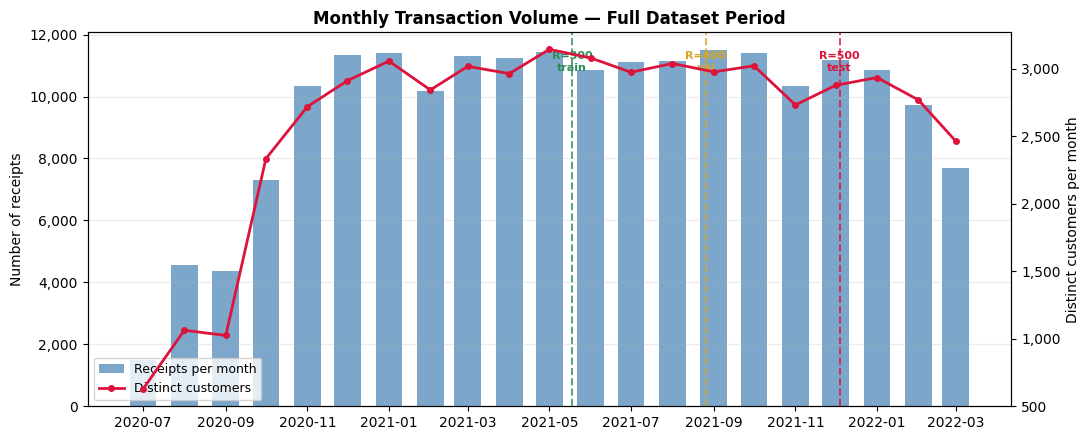

Saved: /tmp/fig_monthly_transaction_volume.png


In [0]:
%python
import pandas as pd
import base64

monthly_df = spark.sql("""
    SELECT DATE_FORMAT(purchased_at, 'yyyy-MM') AS ym,
        COUNT(DISTINCT receipt_id) AS n_receipts,
        COUNT(DISTINCT customer_id) AS n_customers,
        ROUND(SUM(value_clean), 0) AS total_spend
    FROM ml34.v_transactions
    WHERE is_value_outlier = 0 GROUP BY DATE_FORMAT(purchased_at, 'yyyy-MM') ORDER BY ym
""").toPandas()
monthly_df["ym_dt"] = pd.to_datetime(monthly_df["ym"])
monthly_df["total_spend"] = pd.to_numeric(monthly_df["total_spend"], errors="coerce")

fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.bar(
    monthly_df["ym_dt"],
    monthly_df["n_receipts"],
    width=20,
    alpha=0.7,
    color="steelblue",
    label="Receipts per month",
)
ax1.set_ylabel("Number of receipts")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax1.grid(axis="y", alpha=0.25)

ax2 = ax1.twinx()
ax2.plot(
    monthly_df["ym_dt"],
    monthly_df["n_customers"],
    color="crimson",
    marker="o",
    markersize=4,
    linewidth=2,
    label="Distinct customers",
)
ax2.set_ylabel("Distinct customers per month")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

anchor = pd.Timestamp("2020-07-22")
for R, label, col in [
    (300, "R=300\ntrain", "seagreen"),
    (400, "R=400\nval", "goldenrod"),
    (500, "R=500\ntest", "crimson")
]:
    ref_dt = anchor + pd.Timedelta(days=R)

    ax1.axvline(
        ref_dt,
        linestyle="--",
        linewidth=1.4,
        color=col,
        alpha=0.8
    )

    ax1.text(
        ref_dt,
        ax1.get_ylim()[1] * 0.95,
        label,
        color=col,
        fontsize=8,
        ha="center",
        va="top",
        fontweight="bold"
    )

ax1.set_title("Monthly Transaction Volume — Full Dataset Period", fontweight="bold")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="lower left",
    fontsize=9
)
plt.tight_layout()

fig_path = "/tmp/fig_monthly_transaction_volume.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

## Beta Justification
To choose β, I first look at the empirical distribution of inter-visit gaps across all customers:
- Compute each customer's median gap between consecutive shopping visits
- Plot the distribution of these median gaps across the customer base
- Use this to anchor β at a point that is meaningfully longer than the typical shopping cycle


In [0]:
%sql
WITH daily_visits AS ( SELECT DISTINCT customer_id, day FROM ml34.v_transactions),
visit_gaps AS ( SELECT customer_id, day, LEAD(day) OVER (PARTITION BY customer_id ORDER BY day) AS next_day FROM daily_visits),
gap_summary AS (
    SELECT customer_id, PERCENTILE_APPROX(next_day - day, 0.5) AS median_gap_days  -- Median gap between visits for each customer
    FROM visit_gaps
    WHERE next_day IS NOT NULL  -- Exclude the customer's final visit (no next visit to measure)
    GROUP BY customer_id
)
SELECT COUNT(*) AS customers_with_gap_data,
    ROUND(AVG(median_gap_days), 1) AS mean_of_median_gaps,
    ROUND(PERCENTILE_APPROX(median_gap_days, 0.25), 1) AS p25_median_gap,
    ROUND(PERCENTILE_APPROX(median_gap_days, 0.50), 1) AS p50_median_gap,
    ROUND(PERCENTILE_APPROX(median_gap_days, 0.75), 1) AS p75_median_gap,
    ROUND(MAX(median_gap_days),    1) AS max_median_gap
FROM gap_summary;

customers_with_gap_data,mean_of_median_gaps,p25_median_gap,p50_median_gap,p75_median_gap,max_median_gap
6254,45.6,7,18,50,583


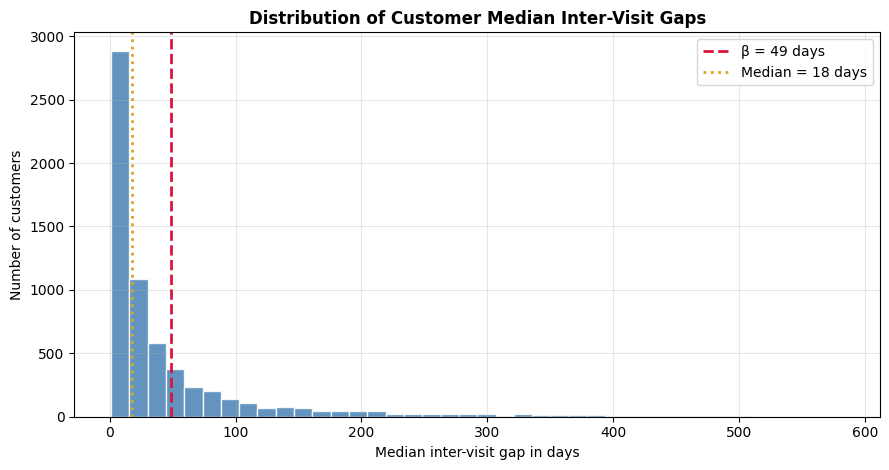

Saved: /tmp/fig_inter_visit_gap_distribution.png
Customers with gap data: 6,254
Median gap: 18.0 days
P75 gap: 50.0 days


In [0]:
%python

import matplotlib.pyplot as plt
import pandas as pd
import base64

gap_df = spark.sql("""WITH daily_visits AS ( SELECT DISTINCT customer_id, day FROM ml34.v_transactions),
visit_gaps AS (SELECT customer_id,day, LEAD(day) OVER (PARTITION BY customer_id ORDER BY day) AS next_day FROM daily_visits),
median_gaps AS ( SELECT customer_id, PERCENTILE_APPROX(next_day - day, 0.5) AS median_gap_days
FROM visit_gaps
WHERE next_day IS NOT NULL
GROUP BY customer_id)
SELECT * FROM median_gaps""").toPandas()

gap_df["median_gap_days"] = pd.to_numeric(gap_df["median_gap_days"], errors="coerce")
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.hist(
    gap_df["median_gap_days"],
    bins=40,
    alpha=0.85,
    color="steelblue",
    edgecolor="white"
)
ax.axvline(
    49,
    linestyle="--",
    linewidth=2,
    color="crimson",
    label="β = 49 days"
)
median_gap = gap_df["median_gap_days"].median()

ax.axvline(
    median_gap,
    linestyle=":",
    linewidth=2,
    color="goldenrod",
    label=f"Median = {median_gap:.0f} days"
)
ax.set_title("Distribution of Customer Median Inter-Visit Gaps", fontweight="bold")
ax.set_xlabel("Median inter-visit gap in days")
ax.set_ylabel("Number of customers")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

fig_path = "/tmp/fig_inter_visit_gap_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")
print(f"Customers with gap data: {len(gap_df):,}")
print(f"Median gap: {median_gap:.1f} days")
print(f"P75 gap: {gap_df['median_gap_days'].quantile(0.75):.1f} days")

In [0]:
%python
BETA = 49 # chosen because it is close to the upper-quartile customer inter-visit gap
DAY_MIN = 0
DAY_MAX = 608 # 2022-02-01

R_MAX = DAY_MAX - BETA  # latest valid reference day that still leaves a full future beta window for labelling

R_MIN_APPROX = 42 # Approximate lower bound for later feature engineering.

print(f"Fixed β / churn inactivity threshold: {BETA} days")
print(f"Observed day index range: {DAY_MIN} to {DAY_MAX}")
print(f"Maximum reference day R_MAX: {R_MAX}")
print(f"Approximate R_MAX date: 2022-02-01")
print(f"Approximate minimum reference day: {R_MIN_APPROX}")
print(f"Usable reference-day span: {R_MAX - R_MIN_APPROX} days")

Fixed β / churn inactivity threshold: 49 days
Observed day index range: 0 to 608
Maximum reference day R_MAX: 559
Approximate R_MAX date: 2022-02-01
Approximate minimum reference day: 42
Usable reference-day span: 517 days


In [0]:
%sql
WITH daily_visits AS (SELECT DISTINCT customer_id, day FROM ml34.v_transactions),
visit_gaps AS ( SELECT customer_id, day, LEAD(day) OVER (PARTITION BY customer_id ORDER BY day) AS next_day
    FROM daily_visits),

median_gaps AS (SELECT customer_id, PERCENTILE_APPROX(next_day - day, 0.5) AS median_gap_days
    FROM visit_gaps
    WHERE next_day IS NOT NULL
    GROUP BY customer_id),

beta_thresholds AS (SELECT 7 AS beta_days
    UNION ALL SELECT 18
    UNION ALL SELECT 26
    UNION ALL SELECT 49)

SELECT b.beta_days,
    ROUND(100.0 * SUM(CASE WHEN m.median_gap_days <= b.beta_days THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_customers_within
    FROM beta_thresholds b
    CROSS JOIN median_gaps m
    GROUP BY b.beta_days
    ORDER BY b.beta_days;

beta_days,pct_customers_within
7,27.31
18,50.14
26,59.58
49,74.85


## Label Construction

In [0]:
%sql
WITH last_purchase_before_R AS (SELECT customer_id, MAX(day) AS last_purchase_day
    FROM ml34.v_transactions
    WHERE day <= 400
    GROUP BY customer_id)

SELECT
    COUNT(*) AS total_customers_ever_seen_by_R,
    SUM(CASE WHEN (400 - last_purchase_day) <= 49 THEN 1 ELSE 0 END) AS active_at_R,
    SUM(CASE WHEN (400 - last_purchase_day) > 49 THEN 1 ELSE 0 END) AS already_churned_at_R,
    ROUND(100.0 * SUM(CASE WHEN (400 - last_purchase_day) <= 49 THEN 1 ELSE 0 END) / COUNT(*), 2) AS pct_still_active
FROM last_purchase_before_R;

total_customers_ever_seen_by_R,active_at_R,already_churned_at_R,pct_still_active
7288,3641,3647,49.96


In [0]:
%sql
WITH last_purchase_before_R AS (SELECT customer_id, MAX(day) AS last_purchase_day
    FROM ml34.v_transactions
    WHERE day <= 400
    GROUP BY customer_id),

active_customers AS (SELECT customer_id
    FROM last_purchase_before_R
    WHERE (400 - last_purchase_day) <= 49),

purchase_within_beta AS (SELECT customer_id, MIN(day) AS first_return_within_beta_day
    FROM ml34.v_transactions
    WHERE day > 400 AND day <= 400 + 49
    GROUP BY customer_id)

SELECT a.customer_id, CASE WHEN p.first_return_within_beta_day IS NULL THEN 1 ELSE 0 END AS churn_label
FROM active_customers a
LEFT JOIN purchase_within_beta p ON a.customer_id = p.customer_id
LIMIT 20;

customer_id,churn_label
15046,0
9900,0
1593,0
15554,0
9724,0
14333,0
6620,0
4957,0
11357,1
8607,1


In [0]:
%sql
WITH last_purchase_before_R AS (SELECT customer_id, MAX(day) AS last_purchase_day
    FROM ml34.v_transactions
    WHERE day <= 400
    GROUP BY customer_id),

active_customers AS (SELECT customer_id
    FROM last_purchase_before_R
    WHERE (400 - last_purchase_day) <= 49),

purchase_within_beta AS ( SELECT customer_id, MIN(day) AS first_return_within_beta_day
    FROM ml34.v_transactions
    WHERE day > 400 AND day <= 400 + 49
    GROUP BY customer_id),

labels AS (SELECT a.customer_id, CASE WHEN p.first_return_within_beta_day IS NULL THEN 1 ELSE 0 END AS churn_label
    FROM active_customers a
    LEFT JOIN purchase_within_beta p ON a.customer_id = p.customer_id)

SELECT COUNT(*) AS active_customers_at_R, SUM(churn_label) AS churners, COUNT(*) - SUM(churn_label) AS non_churners,
    ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) AS churn_rate_pct,
    ROUND(100.0 * (COUNT(*) - SUM(churn_label)) / COUNT(*), 2) AS retention_rate_pct

FROM labels;

active_customers_at_R,churners,non_churners,churn_rate_pct,retention_rate_pct
3641,1062,2579,29.17,70.83


In [0]:
%sql
CREATE OR REPLACE TABLE ml34.labels_R400 AS
WITH last_purchase_before_R AS ( SELECT customer_id, MAX(day) AS last_purchase_day
    FROM ml34.v_transactions
    WHERE day <= 400
    GROUP BY customer_id),

active_customers AS (SELECT customer_id
    FROM last_purchase_before_R
    WHERE (400 - last_purchase_day) <= 49),

purchase_within_beta AS (SELECT customer_id, MIN(day) AS first_return_within_beta_day
    FROM ml34.v_transactions
    WHERE day > 400 AND day <= 400 + 49
    GROUP BY customer_id)

SELECT a.customer_id, 400 AS reference_day, CASE WHEN p.first_return_within_beta_day IS NULL THEN 1 ELSE 0 END AS churn_label
FROM active_customers a
LEFT JOIN purchase_within_beta p ON a.customer_id = p.customer_id; -- customers with no future purchase are retained and labelled as churned

num_affected_rows,num_inserted_rows


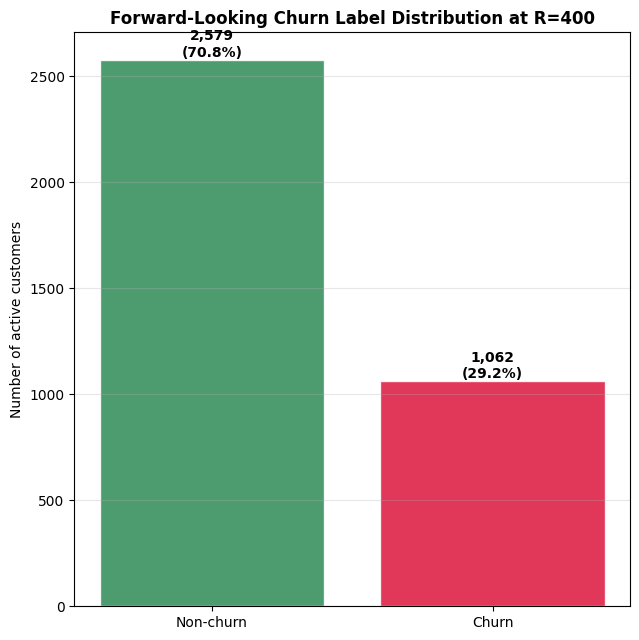

Saved: /tmp/fig_churn_label_balance_r400.png


In [0]:
%python

import matplotlib.pyplot as plt
import pandas as pd
import base64

label_dist_r400 = spark.sql("""SELECT churn_label, COUNT(*) AS n
    FROM ml34.labels_R400
    GROUP BY churn_label
    ORDER BY churn_label""").toPandas()

label_dist_r400["label"] = label_dist_r400["churn_label"].map({
    0: "Non-churn",
    1: "Churn"})

label_dist_r400["pct"] = (100 * label_dist_r400["n"] / label_dist_r400["n"].sum())
fig, ax = plt.subplots(figsize=(6.5, 6.5))
bars = ax.bar(label_dist_r400["label"],
    label_dist_r400["n"],
    color=["seagreen", "crimson"],
    alpha=0.85,
    edgecolor="white")

ax.set_title("Forward-Looking Churn Label Distribution at R=400", fontweight="bold")
ax.set_ylabel("Number of active customers")
ax.grid(axis="y", alpha=0.3)

for bar, n, pct in zip(bars, label_dist_r400["n"],label_dist_r400["pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0,f"{int(n):,}\n({pct:.1f}%)", ha="center", va="bottom", fontweight="bold")
plt.tight_layout()

fig_path = "/tmp/fig_churn_label_balance_r400.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")
print(f"Saved: {fig_path}")

In [0]:
%sql
SELECT churn_label, COUNT(*) AS n, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
FROM ml34.labels_R400
GROUP BY churn_label
ORDER BY churn_label;

churn_label,n,pct
0,2579,70.83
1,1062,29.17


## Beta Sensitivity Analysis
Before committing to β=49, I run a sensitivity check across several candidate values.
The goal is to confirm that:
- The churn rate stays within a reasonable range (neither ~5% nor ~95%, which would make modelling difficult)
- The total number of active customers at R is large enough to train on
- β=49 is not an arbitrary outlier in terms of class balance


In [0]:
%python

BETA_CANDIDATES = [18, 26, 30, 35, 40, 49]
R_SENSITIVITY = 400
beta_rows = []

for beta in BETA_CANDIDATES:
    q = f"""
    WITH last_purchase AS (SELECT customer_id, MAX(day) AS last_day
        FROM ml34.v_transactions
        WHERE day <= {R_SENSITIVITY}
        GROUP BY customer_id),

    active AS (SELECT customer_id
        FROM last_purchase
        WHERE ({R_SENSITIVITY} - last_day) <= {beta}),

    purchase_within_beta AS (SELECT customer_id, MIN(day) AS first_return_within_beta_day
        FROM ml34.v_transactions
        WHERE day > {R_SENSITIVITY} AND day <= {R_SENSITIVITY} + {beta}
        GROUP BY customer_id),

    labels AS (SELECT a.customer_id, CASE WHEN p.first_return_within_beta_day IS NULL THEN 1 ELSE 0 END AS churn_label
        FROM active a
        LEFT JOIN purchase_within_beta p ON a.customer_id = p.customer_id)

    SELECT {beta} AS beta_days,
        COUNT(*) AS active_customers,
        SUM(churn_label) AS churners,
        COUNT(*) - SUM(churn_label) AS non_churners,
        ROUND(100.0 * SUM(churn_label) / COUNT(*), 2) AS churn_rate_pct,
        ROUND(100.0 * (COUNT(*) - SUM(churn_label)) / COUNT(*), 2) AS retention_rate_pct
        FROM labels
    """

    row = spark.sql(q).toPandas().iloc[0].to_dict()
    beta_rows.append(row)
beta_sensitivity_df = pd.DataFrame(beta_rows)

print("BETA SENSITIVITY ANALYSIS AT R=400")
print("=" * 80)
print(beta_sensitivity_df.to_string(index=False))

BETA SENSITIVITY ANALYSIS AT R=400
 beta_days  active_customers  churners  non_churners churn_rate_pct retention_rate_pct
        18              2437       910          1527          37.34              62.66
        26              2873       974          1899          33.90              66.10
        30              3016       984          2032          32.63              67.37
        35              3179       989          2190          31.11              68.89
        40              3346      1013          2333          30.27              69.73
        49              3641      1062          2579          29.17              70.83


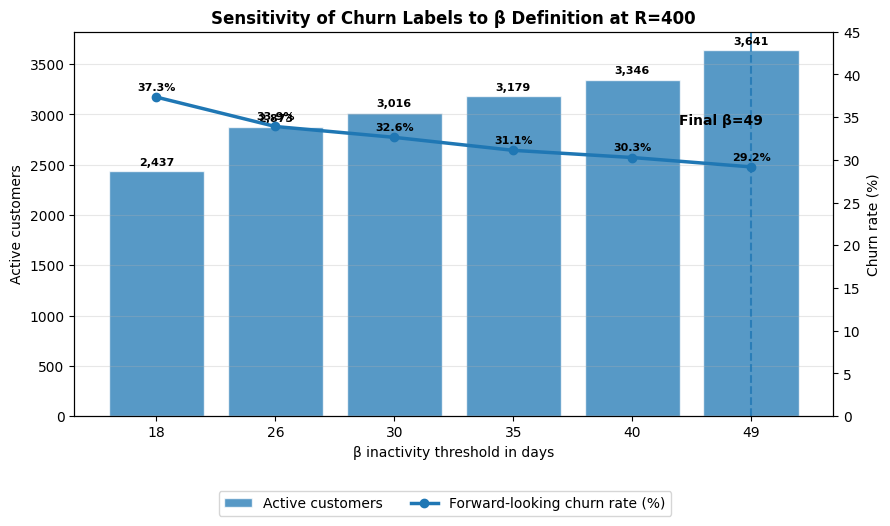

Saved: /tmp/fig_beta_sensitivity.png


In [0]:
%python
import numpy as np

plot_df = beta_sensitivity_df.copy()

numeric_cols = [    # Convert Spark Decimal values to normal Python numeric types
    "beta_days",
    "active_customers",
    "churners",
    "non_churners",
    "churn_rate_pct",
    "retention_rate_pct",
]

for col in numeric_cols:
    if col in plot_df.columns:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce").astype(float)

fig, ax1 = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(plot_df))

# Bar chart: active customers
bars = ax1.bar(x, plot_df["active_customers"],
    alpha=0.75,
    edgecolor="white",
    label="Active customers")
ax1.set_xlabel("β inactivity threshold in days")
ax1.set_ylabel("Active customers")
ax1.set_xticks(x)
ax1.set_xticklabels(plot_df["beta_days"].astype(int))
ax1.grid(axis="y", alpha=0.3)

# Line chart: churn rate
ax2 = ax1.twinx()
ax2.plot(x, plot_df["churn_rate_pct"],
    marker="o",
    linewidth=2.5,
    label="Forward-looking churn rate (%)")
ax2.set_ylabel("Churn rate (%)")
ax2.set_ylim(0, max(45, float(plot_df["churn_rate_pct"].max()) * 1.2))

# Highlight final β=49
if 49 in plot_df["beta_days"].astype(int).values:
    idx_49 = plot_df.index[plot_df["beta_days"].astype(int) == 49][0]
    ax1.axvline(idx_49,
        linestyle="--",
        linewidth=1.5,
        alpha=0.8)

    ax2.text(idx_49 - 0.25, float(plot_df.loc[idx_49, "churn_rate_pct"]) + 5, "Final β=49",
        ha="center",
        fontweight="bold")

# labels for active customer bars
for i, row in plot_df.iterrows():
    ax1.text(i, float(row["active_customers"]) + 60, f"{int(row['active_customers']):,}",
        ha="center",
        fontsize=8,
        fontweight="bold")

# labels for churn-rate line
for i, row in plot_df.iterrows():
    ax2.text(i, float(row["churn_rate_pct"]) + 0.8, f"{float(row['churn_rate_pct']):.1f}%",
        ha="center",
        fontsize=8,
        fontweight="bold")
ax1.set_title("Sensitivity of Churn Labels to β Definition at R=400", fontweight="bold")

fig.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=2)

plt.tight_layout()

# Save locally and embed using base64
fig_path = "/tmp/fig_beta_sensitivity.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")
print(f"Saved: {fig_path}")

## Feature Engineering
I use a combination of:

**Lifetime / tenure features** (whole history up to R):
- `total_visits_lifetime` — total number of distinct shopping days
- `total_spend_lifetime` — cumulative spend (excluding sentinel values)
- `avg_gap_lifetime` — average inter-visit gap in days
- `customer_tenure_days` — days from first purchase to R

**Recency feature:**
- `days_since_last_purchase` — how many days before R was the customer's most recent visit

**Short-window features (4 windows, each ~14 days):**
- `visits_w1`, `visits_w2`, `visits_w3`, `visits_w4` — visit frequency per window
- `spend_w1`, `spend_w2`, ..., `qty_w1`, `qty_w2`, ... — spend and quantity per window
- `avg_basket_w1`, `avg_basket_w2`, ... — average basket value per window

**Derived ratio/trend features:**
- `spend_ratio_w1w2` — ratio of most recent window spend to prior window (captures spend decline)
- `spend_trend_w1w2` — absolute spend difference between w1 and w2

**Breadth features (over 56-day lookback):**
- `n_products_56d` — number of distinct products purchased
- `n_categories_56d` — number of distinct product categories
- `n_stores_56d` — number of distinct stores visited

## Train / Validation / Test Split
I use three fixed reference days rather than a random split:

| Split | Reference Day R | Approximate Date |
|---|---|---|
| **Train** | R = 300 | ~May 2021 |
| **Validation** | R = 400 | ~Aug 2021 |
| **Test** | R = 500 | ~Dec 2021 |

In [0]:
%python
BETA        = 49     # inactivity threshold in days
DAY_MIN     = 0
DAY_MAX     = 608
ANCHOR_DATE = '2020-07-22'   # day 0 in the dataset

# Reference dates for temporal holdout
R_TRAIN = 300
R_VAL   = 400   # labels_R400 already exists
R_TEST  = 500

# Tumbling window design
W_SIZE    = 14   # size of each tumbling window (days)
N_WINDOWS = 4    # number of windows (4 x 14 = 56 days observation window)
OBS_WINDOW = W_SIZE * N_WINDOWS   # = 56 days total feature history

# Feature column list
FEATURE_COLS = [
    'days_since_last_purchase', # Recency
    'spend_w1', 'spend_w2', 'spend_w3', 'spend_w4', # Spend per tumbling window
    'visits_w1', 'visits_w2', 'visits_w3', 'visits_w4', # Visits per tumbling window
    'qty_w1', 'qty_w2', # Quantity per window
    'avg_basket_w1', 'avg_basket_w2', 'avg_items_per_visit_w1', # Basket features
    'spend_trend_w1w2', 'spend_trend_w1w3', # Trend features (w1 - w2, w1 - w3, ratios)
    'visit_trend_w1w2', 'visit_trend_w1w3',
    'spend_ratio_w1w2',
    'n_categories_56d', 'n_subcategories_56d',  # Diversity over 56-day observation window
    'n_departments_56d', 'n_stores_56d', 'n_products_56d',
    'total_visits_lifetime', 'total_spend_lifetime',    # Lifetime features
    'avg_gap_lifetime', 'customer_tenure_days',
    'age_at_R', # Demographic
]
print(f"BETA: {BETA} days")
print(f"R_TRAIN: day {R_TRAIN} ({ANCHOR_DATE} + {R_TRAIN} days)")
print(f"R_VAL: day {R_VAL}")
print(f"R_TEST: day {R_TEST}")
print(f"Observation window:{OBS_WINDOW} days ({N_WINDOWS} x {W_SIZE}-day tumbling windows)")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"\nLabel window check:")
for R in [R_TRAIN, R_VAL, R_TEST]:
    ok = "[okay]" if R + BETA <= DAY_MAX else "[EXCEEDS DATASET]"
    print(f"R={R}: output window = ({R}, {R+BETA}] — max day needed = {R+BETA} {ok}")

BETA: 49 days
R_TRAIN: day 300 (2020-07-22 + 300 days)
R_VAL: day 400
R_TEST: day 500
Observation window:56 days (4 x 14-day tumbling windows)
Feature columns: 29

Label window check:
R=300: output window = (300, 349] — max day needed = 349 [okay]
R=400: output window = (400, 449] — max day needed = 449 [okay]
R=500: output window = (500, 549] — max day needed = 549 [okay]


In [0]:
%python
print("TEMPORAL WINDOW DIAGRAM")
print("=" * 72)
print(f"Day axis: 0 = {ANCHOR_DATE}   DAY_MAX = {DAY_MAX} = 2022-03-22")
print()

for R in [R_TRAIN, R_VAL, R_TEST]:
    label = {R_TRAIN: "TRAIN", R_VAL: "VAL  ", R_TEST: "TEST "}[R]
    obs_start = R - OBS_WINDOW
    label_end = R + BETA

    print(f"R_{label}  (day {R:>3}):")
    print(f"Feature window: ({obs_start:>4}, {R:>4}]  "
          f"({N_WINDOWS} x {W_SIZE}-day tumbling windows)")
    print(f"Reference date: {R:>4}")
    print(f"Label window: ({R:>4}, {label_end:>4}]  "
          f"(does customer return within {BETA} days?)")
    print()

TEMPORAL WINDOW DIAGRAM
Day axis: 0 = 2020-07-22   DAY_MAX = 608 = 2022-03-22

R_TRAIN  (day 300):
Feature window: ( 244,  300]  (4 x 14-day tumbling windows)
Reference date:  300
Label window: ( 300,  349]  (does customer return within 49 days?)

R_VAL    (day 400):
Feature window: ( 344,  400]  (4 x 14-day tumbling windows)
Reference date:  400
Label window: ( 400,  449]  (does customer return within 49 days?)

R_TEST   (day 500):
Feature window: ( 444,  500]  (4 x 14-day tumbling windows)
Reference date:  500
Label window: ( 500,  549]  (does customer return within 49 days?)



In [0]:
%python
def build_feature_sql(R, beta=49, w_size=14, n_windows=4):
    obs_start = R - n_windows * w_size  # start of observation window

    # Compute (lower_exclusive, upper_inclusive) bounds for each window
    # w1 is most recent, w4 is oldest
    bounds = [(R - k * w_size, R - (k - 1) * w_size) for k in range(1, n_windows + 1)]
    # bounds[0] = (R-14, R]   → w1 is most recent 14-day window before 
    # w2, w3 and w4 move progressively further back in time
    # bounds[1] = (R-28, R-14] → w2
    # bounds[2] = (R-42, R-28] → w3
    # bounds[3] = (R-56, R-42] → w4
    b = bounds  # shorthand

    sql = f"""WITH last_purchase AS(SELECT customer_id, MAX(day) AS last_day
        FROM ml34.v_transactions
        WHERE day <= {R}
        GROUP BY customer_id),

    active AS (SELECT customer_id, last_day
        FROM last_purchase
        WHERE ({R} - last_day) <= {beta}),

        -- Keeping windows relative to R avoids data leakage across train, validation and test splits
    window_aggs AS (SELECT t.customer_id,
            SUM(CASE WHEN t.day > {b[0][0]} AND t.day <= {b[0][1]}      -- SPEND (sum of value_clean; negative values = returns, included)
                     THEN COALESCE(t.value_clean, 0) ELSE 0 END) AS spend_w1,
            SUM(CASE WHEN t.day > {b[1][0]} AND t.day <= {b[1][1]}
                     THEN COALESCE(t.value_clean, 0) ELSE 0 END) AS spend_w2,
            SUM(CASE WHEN t.day > {b[2][0]} AND t.day <= {b[2][1]}
                     THEN COALESCE(t.value_clean, 0) ELSE 0 END) AS spend_w3,
            SUM(CASE WHEN t.day > {b[3][0]} AND t.day <= {b[3][1]}
                     THEN COALESCE(t.value_clean, 0) ELSE 0 END) AS spend_w4,

            -- VISITS (distinct purchase days per window, not receipt count)
            COUNT(DISTINCT CASE WHEN t.day > {b[0][0]} AND t.day <= {b[0][1]}   
                                THEN t.day END) AS visits_w1,
            COUNT(DISTINCT CASE WHEN t.day > {b[1][0]} AND t.day <= {b[1][1]}
                                THEN t.day END) AS visits_w2,
            COUNT(DISTINCT CASE WHEN t.day > {b[2][0]} AND t.day <= {b[2][1]}
                                THEN t.day END) AS visits_w3,
            COUNT(DISTINCT CASE WHEN t.day > {b[3][0]} AND t.day <= {b[3][1]}
                                THEN t.day END) AS visits_w4,

            -- QUANTITY (total items purchased per window)
            SUM(CASE WHEN t.day > {b[0][0]} AND t.day <= {b[0][1]}  
                     THEN t.qty ELSE 0 END) AS qty_w1,
            SUM(CASE WHEN t.day > {b[1][0]} AND t.day <= {b[1][1]}
                     THEN t.qty ELSE 0 END) AS qty_w2,
            SUM(CASE WHEN t.day > {b[2][0]} AND t.day <= {b[2][1]}
                     THEN t.qty ELSE 0 END) AS qty_w3,
            SUM(CASE WHEN t.day > {b[3][0]} AND t.day <= {b[3][1]}
                     THEN t.qty ELSE 0 END) AS qty_w4,

            -- DIVERSITY over full {n_windows * w_size}-day observation window; these measure product/shopping breadth as churn signals
            COUNT(DISTINCT CASE WHEN t.day > {obs_start} AND t.day <= {R}   
                                THEN t.category_code END) AS n_categories_56d,
            COUNT(DISTINCT CASE WHEN t.day > {obs_start} AND t.day <= {R}
                                THEN t.sub_category_code END) AS n_subcategories_56d,
            COUNT(DISTINCT CASE WHEN t.day > {obs_start} AND t.day <= {R}
                                THEN t.department_code END) AS n_departments_56d,
            COUNT(DISTINCT CASE WHEN t.day > {obs_start} AND t.day <= {R}
                                THEN t.store_code END) AS n_stores_56d,
            COUNT(DISTINCT CASE WHEN t.day > {obs_start} AND t.day <= {R}
                                THEN t.product_code END) AS n_products_56d
        FROM ml34.v_transactions t
        INNER JOIN active a ON t.customer_id = a.customer_id
        WHERE t.day <= {R}      -- enforces no leakage from future transactions
        GROUP BY t.customer_id),

    lifetime_aggs AS (SELECT t.customer_id, MIN(t.day) AS first_day, COUNT(DISTINCT t.day) AS total_visits_lifetime, SUM(COALESCE(t.value_clean, 0)) AS total_spend_lifetime,
            CASE WHEN COUNT(DISTINCT t.day) > 1 THEN CAST(MAX(t.day) - MIN(t.day) AS DOUBLE) / (COUNT(DISTINCT t.day) - 1) ELSE 0.0
            END AS avg_gap_lifetime
        FROM ml34.v_transactions t
        INNER JOIN active a ON t.customer_id = a.customer_id
        WHERE t.day <= {R}
        GROUP BY t.customer_id)

    SELECT a.customer_id, {R} AS reference_day, ({R} - a.last_day) AS days_since_last_purchase,
        w.spend_w1, w.spend_w2, w.spend_w3, w.spend_w4,
        w.visits_w1, w.visits_w2, w.visits_w3, w.visits_w4,
        w.qty_w1, w.qty_w2, w.qty_w3, w.qty_w4,
        CASE WHEN w.visits_w1 > 0 THEN w.spend_w1 / w.visits_w1 ELSE 0 END AS avg_basket_w1,
        CASE WHEN w.visits_w2 > 0 THEN w.spend_w2 / w.visits_w2 ELSE 0 END AS avg_basket_w2,
        CASE WHEN w.visits_w1 > 0 THEN CAST(w.qty_w1 AS DOUBLE) / w.visits_w1 ELSE 0 END AS avg_items_per_visit_w1,

        (w.spend_w1  - w.spend_w2) AS spend_trend_w1w2,
        (w.spend_w1  - w.spend_w3) AS spend_trend_w1w3,
        (w.visits_w1 - w.visits_w2) AS visit_trend_w1w2,
        (w.visits_w1 - w.visits_w3) AS visit_trend_w1w3,

        CASE WHEN w.spend_w2 != 0 THEN w.spend_w1 / w.spend_w2 ELSE 0 END AS spend_ratio_w1w2,

        w.n_categories_56d,
        w.n_subcategories_56d,
        w.n_departments_56d,
        w.n_stores_56d,
        w.n_products_56d,

        l.total_visits_lifetime,
        l.total_spend_lifetime,
        l.avg_gap_lifetime,
        ({R} - l.first_day) AS customer_tenure_days,
        DATEDIFF(DATE_ADD(DATE('2020-07-22'), {R}), c.dob) / 365.25 AS age_at_R

    FROM active a
    LEFT JOIN window_aggs   w  ON a.customer_id = w.customer_id
    LEFT JOIN lifetime_aggs l  ON a.customer_id = l.customer_id
    LEFT JOIN ml34.customers c ON a.customer_id = c.customer_id
    """
    return sql

print("build_feature_sql() defined.")
print(f"Feature window at R=300: days ({300 - 56}, {300}] "
      f"(w1: ({300-14},{300}], w2: ({300-28},{300-14}], "
      f"w3: ({300-42},{300-28}], w4: ({300-56},{300-42}])")

build_feature_sql() defined.
Feature window at R=300: days (244, 300] (w1: (286,300], w2: (272,286], w3: (258,272], w4: (244,258])


In [0]:
%python

def save_features(R, beta=BETA, w_size=W_SIZE, n_windows=N_WINDOWS):
    feat_sql = build_feature_sql(R, beta, w_size, n_windows)

    create_sql = f"""
    CREATE OR REPLACE TABLE ml34.features_R{R} AS
    {feat_sql}
    """
    spark.sql(create_sql)
    n_rows = spark.sql(f"""
        SELECT COUNT(*) AS n
        FROM ml34.features_R{R}
    """).collect()[0]["n"]
    print(f"features_R{R}: {n_rows:,} rows saved")
    return n_rows

print("save_features() defined.")

save_features() defined.


In [0]:
%python

def save_labels(R, beta=BETA):

    create_sql = f"""CREATE OR REPLACE TABLE ml34.labels_R{R} AS WITH last_purchase AS (SELECT customer_id, MAX(day) AS last_day
        FROM ml34.v_transactions
        WHERE day <= {R}
        GROUP BY customer_id),

    active AS (SELECT customer_id
        FROM last_purchase
        WHERE ({R} - last_day) <= {beta}),

    purchase_within_beta AS (SELECT customer_id, MIN(day) AS first_return_within_beta_day
        FROM ml34.v_transactions
        WHERE day > {R} AND day <= {R} + {beta}
        GROUP BY customer_id)

    SELECT a.customer_id, {R} AS reference_day, CASE WHEN p.first_return_within_beta_day IS NULL THEN 1 ELSE 0 END AS churn_label
    FROM active a
    LEFT JOIN purchase_within_beta p ON a.customer_id = p.customer_id"""

    spark.sql(create_sql)

    dist = spark.sql(f"""SELECT churn_label, COUNT(*) AS n, ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
        FROM ml34.labels_R{R}
        GROUP BY churn_label
        ORDER BY churn_label""").toPandas()

    print(f"\n labels_R{R} — class distribution:")
    for _, row in dist.iterrows():
        label_str = "Non-churn (0)" if row.churn_label == 0 else "Churn (1)"
        print(f"{label_str}: {int(row.n):>5,} rows({row.pct}%)")
    return dist

print("save_labels() defined.")

save_labels() defined.


In [0]:
%python
import pandas as pd

def load_dataset(R):

    df = spark.sql(f"""SELECT f.*, l.churn_label
        FROM   ml34.features_R{R}  f
        INNER JOIN ml34.labels_R{R} l ON f.customer_id = l.customer_id""").toPandas()

    # Separate features, labels, and identifiers
    id_cols   = ['customer_id', 'reference_day']
    label_col = 'churn_label'
    feat_cols = [c for c in df.columns if c not in id_cols + [label_col]]

    X = df[feat_cols].copy()
    y = df[label_col].copy()
    ids= df['customer_id'].copy()

    churn_rate = y.mean()
    n_feat     = X.shape[1]
    null_count = X.isnull().sum().sum()

    print(f"  R={R}: {len(df):,} rows | {n_feat} features | "
          f"churn rate = {churn_rate:.1%} | nulls = {null_count}")

    # Assert no join mismatch
    n_feat_table  = spark.sql(f"SELECT COUNT(*) AS n FROM ml34.features_R{R}") \
                         .collect()[0]["n"]
    n_label_table = spark.sql(f"SELECT COUNT(*) AS n FROM ml34.labels_R{R}") \
                         .collect()[0]["n"]
    assert len(df) == n_feat_table == n_label_table, \
        f"Row count mismatch: features={n_feat_table}, labels={n_label_table}, joined={len(df)}"
    return X, y, ids

print("load_dataset() defined.")

load_dataset() defined.


In [0]:
%python
print("Building R_TRAIN = 300")
print("-" * 40)
save_features(R_TRAIN)
save_labels(R_TRAIN)

Building R_TRAIN = 300
----------------------------------------
features_R300: 3,694 rows saved

 labels_R300 — class distribution:
Non-churn (0): 2,605 rows(70.52%)
Churn (1): 1,089 rows(29.48%)


,churn_label,n,pct
0,0,2605,70.52
1,1,1089,29.48


In [0]:
%python
print("Building R_VAL = 400")
print("-" * 40)
save_features(R_VAL)
save_labels(R_VAL)

Building R_VAL = 400
----------------------------------------
features_R400: 3,641 rows saved

 labels_R400 — class distribution:
Non-churn (0): 2,579 rows(70.83%)
Churn (1): 1,062 rows(29.17%)


,churn_label,n,pct
0,0,2579,70.83
1,1,1062,29.17


In [0]:
%python
print("Building R_TEST = 500")
print("-" * 40)
save_features(R_TEST)
save_labels(R_TEST)

Building R_TEST = 500
----------------------------------------
features_R500: 3,369 rows saved

 labels_R500 — class distribution:
Non-churn (0): 2,446 rows(72.60%)
Churn (1):   923 rows(27.40%)


,churn_label,n,pct
0,0,2446,72.60
1,1,923,27.40


In [0]:
%python
print("Loading all splits")
print("-" * 40)
X_train, y_train, ids_train = load_dataset(R_TRAIN)
X_val,   y_val,   ids_val   = load_dataset(R_VAL)
X_test,  y_test,  ids_test  = load_dataset(R_TEST)

print(f"\nSplit sizes:")
print(f"  Train : {len(y_train):>5,} rows  (churn={y_train.mean():.1%})")
print(f"  Val   : {len(y_val):>5,} rows  (churn={y_val.mean():.1%})")
print(f"  Test  : {len(y_test):>5,} rows  (churn={y_test.mean():.1%})")

Loading all splits
----------------------------------------
  R=300: 3,694 rows | 31 features | churn rate = 29.5% | nulls = 3236
  R=400: 3,641 rows | 31 features | churn rate = 29.2% | nulls = 3183
  R=500: 3,369 rows | 31 features | churn rate = 27.4% | nulls = 2927

Split sizes:
  Train : 3,694 rows  (churn=29.5%)
  Val   : 3,641 rows  (churn=29.2%)
  Test  : 3,369 rows  (churn=27.4%)


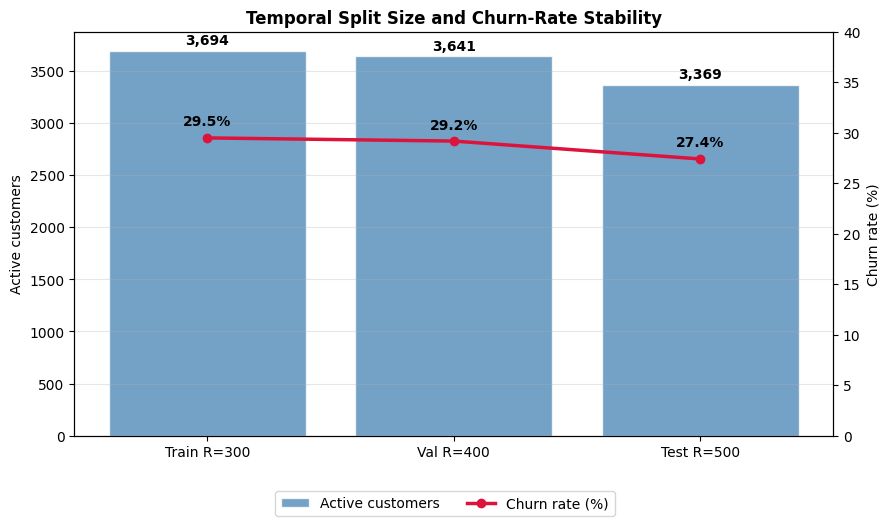

Saved: /tmp/fig_split_churn_stability.png
      split  rows  churn_rate
Train R=300  3694    0.294802
  Val R=400  3641    0.291678
 Test R=500  3369    0.273969


In [0]:
%python
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import base64

split_summary = pd.DataFrame({
    "split": ["Train R=300", "Val R=400", "Test R=500"],
    "rows": [len(y_train), len(y_val), len(y_test)],
    "churn_rate": [y_train.mean(), y_val.mean(), y_test.mean()]})

fig, ax1 = plt.subplots(figsize=(9, 4.8))
x = np.arange(len(split_summary))

bars = ax1.bar(x, split_summary["rows"],
    color="steelblue",
    alpha=0.75,
    edgecolor="white",
    label="Active customers")

ax1.set_ylabel("Active customers")
ax1.set_xticks(x)
ax1.set_xticklabels(split_summary["split"])
ax1.grid(axis="y", alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(x, split_summary["churn_rate"] * 100,
    color="crimson",
    marker="o",
    linewidth=2.5,
    label="Churn rate (%)")

ax2.set_ylabel("Churn rate (%)")
ax2.set_ylim(0, max(40, split_summary["churn_rate"].max() * 120))

for i, row in split_summary.iterrows():
    ax1.text(i, row["rows"] + 60, f"{int(row['rows']):,}",
        ha="center",
        fontweight="bold")
    ax2.text(i, row["churn_rate"] * 100 + 1.2, f"{row['churn_rate']*100:.1f}%",
        ha="center",
        fontweight="bold")

ax1.set_title("Temporal Split Size and Churn-Rate Stability", fontweight="bold")
fig.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=2)
plt.tight_layout()

fig_path = "/tmp/fig_split_churn_stability.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")
print(split_summary.to_string(index=False))

In [0]:
%sql
WITH active_at_300 AS (
    SELECT customer_id, MAX(day) AS true_last_day_before_300
    FROM ml34.v_transactions
    WHERE day <= 300
    GROUP BY customer_id
    HAVING (300 - MAX(day)) <= 49
),

feature_recency AS (
    SELECT customer_id, days_since_last_purchase
    FROM ml34.features_R300
),

cross_check AS (
    SELECT
        a.customer_id,
        a.true_last_day_before_300,
        300 - a.true_last_day_before_300 AS expected_recency,
        f.days_since_last_purchase AS feature_recency,
        ABS((300 - a.true_last_day_before_300) - f.days_since_last_purchase) AS discrepancy
    FROM active_at_300 a
    JOIN feature_recency f ON a.customer_id = f.customer_id
)

SELECT
    COUNT(*) AS customers_checked,
    SUM(CASE WHEN discrepancy > 0 THEN 1 ELSE 0 END) AS leakage_detected,
    MAX(discrepancy) AS max_discrepancy
FROM cross_check;

-- Expected: leakage_detected = 0, max_discrepancy = 0

customers_checked,leakage_detected,max_discrepancy
3694,0,0


In [0]:
%python
import pandas as pd

print("NULL counts per feature column across all three splits:\n")

null_summary = []
for name, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    nulls = X.isnull().sum()
    null_cols = nulls[nulls > 0]
    null_summary.append({'split': name, 'null_cols': len(null_cols), 'total_nulls': nulls.sum()})
    if len(null_cols) > 0:
        print(f"{name}: {len(null_cols)} columns with NULLs")
        for col, n in null_cols.items():
            print(f"{col}: {n} NULLs ({100*n/len(X):.1f}%)\n")
    else:
        print(f"{name}: no NULLs")

NULL counts per feature column across all three splits:

train: 1 columns with NULLs
age_at_R: 3236 NULLs (87.6%)

val: 1 columns with NULLs
age_at_R: 3183 NULLs (87.4%)

test: 1 columns with NULLs
age_at_R: 2927 NULLs (86.9%)



In [0]:
%python
age_col = 'age_at_R'

if X_train[age_col].isnull().any():
    age_median = X_train[age_col].median()
    print(f"Imputing {age_col} with training median = {age_median:.1f} years")
    X_train[age_col] = X_train[age_col].fillna(age_median)
    X_val[age_col] = X_val[age_col].fillna(age_median)
    X_test[age_col] = X_test[age_col].fillna(age_median)
else:
    print(f"No NULLs in {age_col} — no imputation needed.")

print("\nFinal NULL counts after imputation:")
for name, X in [('train', X_train), ('val', X_val), ('test', X_test)]:
    print(f"{name}: {X.isnull().sum().sum()} NULLs")

Imputing age_at_R with training median = 52.1 years

Final NULL counts after imputation:
train: 0 NULLs
val: 0 NULLs
test: 0 NULLs


In [0]:
%python

from decimal import Decimal
X_train_num = X_train.copy()
for col in X_train_num.columns:
    X_train_num[col] = pd.to_numeric(X_train_num[col], errors="coerce").astype(float)

total_nulls_after_conversion = X_train_num.isnull().sum().sum()
print(f"Total NULLs after numeric conversion: {total_nulls_after_conversion}")
if total_nulls_after_conversion > 0:
    print("Filling conversion-created NULLs with 0 for summary comparison only.")
    X_train_num = X_train_num.fillna(0)
comparison = pd.DataFrame({
    "non_churn_mean": X_train_num[y_train == 0].mean(numeric_only=True),
    "churn_mean": X_train_num[y_train == 1].mean(numeric_only=True),})

comparison["diff"] = comparison["churn_mean"] - comparison["non_churn_mean"]
comparison["abs_diff"] = comparison["diff"].abs()

comparison["pct_diff"] = np.where(
    comparison["non_churn_mean"].abs() > 1e-9,
    100 * comparison["diff"] / comparison["non_churn_mean"],
    np.nan)

comparison = comparison.sort_values("abs_diff", ascending=False)

print("\nTop 15 features by mean difference (churners vs non-churners) — TRAIN SET ONLY")
print("-" * 90)
print(f"{'Feature':<32} {'Non-churn mean':>15} {'Churn mean':>15} {'Diff':>12} {'% diff':>10}")
print("-" * 90)

for feat, row in comparison.head(15).iterrows():
    pct = "NA" if pd.isna(row.pct_diff) else f"{row.pct_diff:>8.1f}%"
    print(f"{feat:<32} "
        f"{row.non_churn_mean:>15.3f} "
        f"{row.churn_mean:>15.3f} "
        f"{row['diff']:>12.3f} "
        f"{pct:>10}")

comparison_reset = comparison.reset_index().rename(columns={"index": "feature"})
spark.createDataFrame(comparison_reset).createOrReplaceTempView("feature_comparison_train_tmp")

print("\nSaved comparison as pandas DataFrame: comparison")
print("Also created Spark temp view: feature_comparison_train_tmp")

Total NULLs after numeric conversion: 0

Top 15 features by mean difference (churners vs non-churners) — TRAIN SET ONLY
------------------------------------------------------------------------------------------
Feature                           Non-churn mean      Churn mean         Diff     % diff
------------------------------------------------------------------------------------------
total_spend_lifetime                     452.652          72.996     -379.656     -83.9%
customer_tenure_days                     207.160         120.366      -86.793     -41.9%
n_products_56d                            44.265          16.489      -27.776     -62.8%
total_visits_lifetime                     25.695           4.035      -21.660     -84.3%
spend_w4                                  27.271           5.775      -21.496     -78.8%
spend_w2                                  29.184           8.587      -20.597     -70.6%
spend_w3                                  28.233           8.142      -20.0

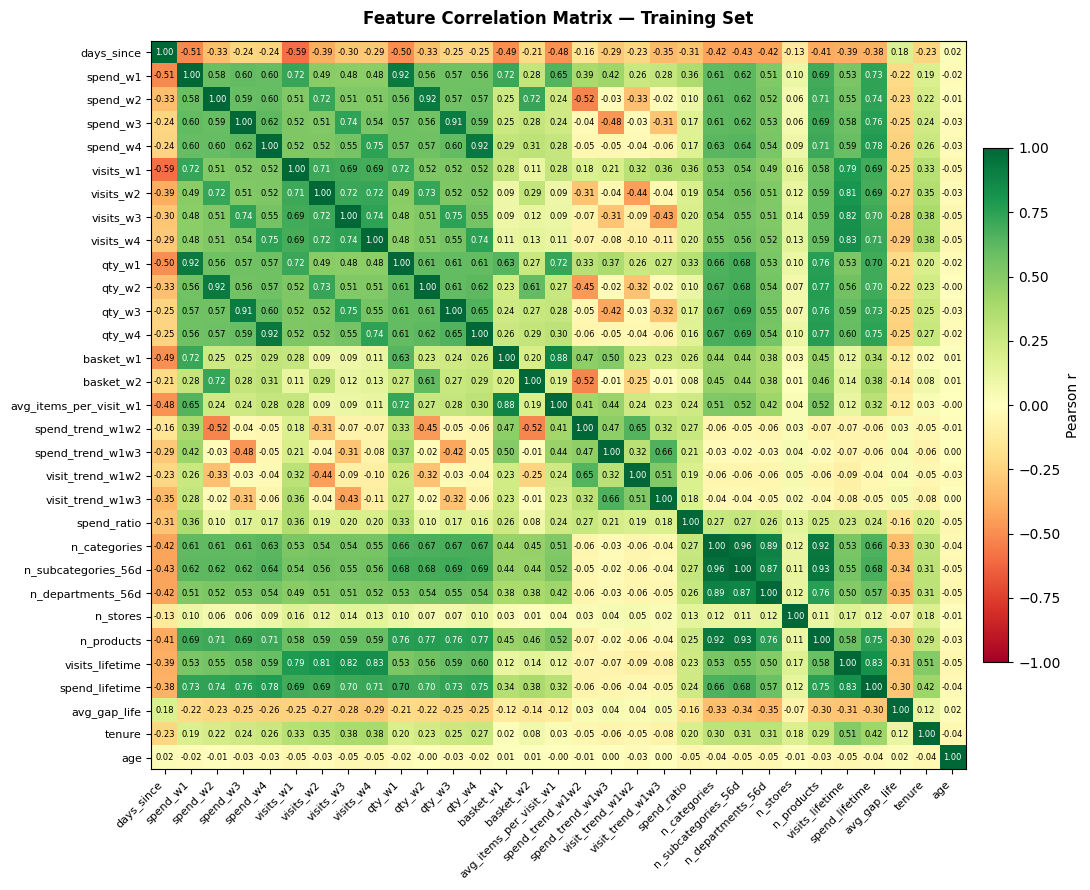

Saved: /tmp/fig_feature_correlation_matrix_train.png


In [0]:
%python

X_corr = X_train.copy()
for col in X_corr.columns:
    X_corr[col] = pd.to_numeric(X_corr[col], errors="coerce").astype(float)
X_corr = X_corr.fillna(0)

X_corr = X_corr.drop(columns=["customer_id"], errors="ignore")
corr_matrix = X_corr.corr()

label_map = {
    "total_visits_lifetime"    : "visits_lifetime",
    "total_spend_lifetime"     : "spend_lifetime",
    "avg_gap_lifetime"         : "avg_gap_life",
    "customer_tenure_days"     : "tenure",
    "days_since_last_purchase" : "days_since",
    "visits_w1"  : "visits_w1",
    "visits_w2"  : "visits_w2",
    "visits_w3"  : "visits_w3",
    "visits_w4"  : "visits_w4",
    "spend_w1"   : "spend_w1",
    "spend_w2"   : "spend_w2",
    "spend_w3"   : "spend_w3",
    "spend_w4"   : "spend_w4",
    "spend_ratio_w1w2"   : "spend_ratio",
    "avg_basket_w1"      : "basket_w1",
    "avg_basket_w2"      : "basket_w2",
    "n_products_56d"     : "n_products",
    "n_categories_56d"   : "n_categories",
    "n_stores_56d"       : "n_stores",
    "age_at_R"           : "age",
}

corr_matrix = corr_matrix.rename(index=label_map, columns=label_map)

fig, ax = plt.subplots(figsize=(11, 9))
cmap = plt.cm.RdYlGn

im = ax.imshow(corr_matrix.values, cmap=cmap, vmin=-1, vmax=1, aspect="auto")

ticks = range(len(corr_matrix.columns))
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        val = corr_matrix.values[i, j]
        color = "black" if abs(val) < 0.7 else "white"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color=color)

plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label="Pearson r")
ax.set_title("Feature Correlation Matrix — Training Set", fontweight="bold", pad=12)
plt.tight_layout()

fig_path = "/tmp/fig_feature_correlation_matrix_train.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

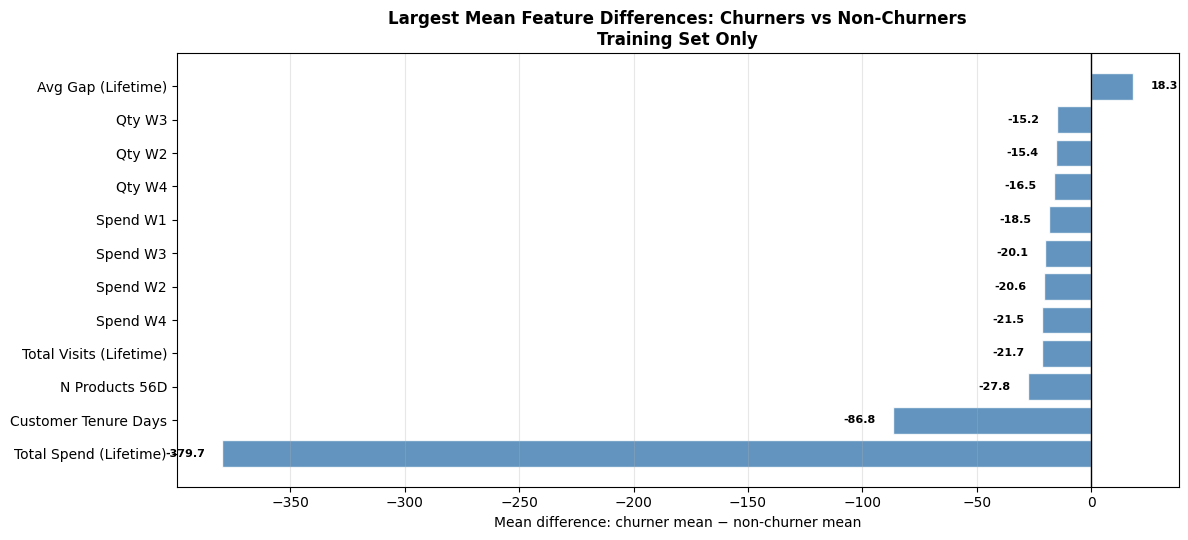

Saved: /tmp/fig_top_feature_differences.png


In [0]:
%python
plot_diff = comparison.reset_index().rename(columns={"index": "feature"}).head(12).copy()

plot_diff["label"] = (plot_diff["feature"].str.replace("_", " ", regex=False).str.replace("lifetime", "(lifetime)", regex=False).str.title())

plot_diff = plot_diff.sort_values("diff")
fig, ax = plt.subplots(figsize=(12, 5.5))

bars = ax.barh(plot_diff["label"], plot_diff["diff"],
    color="steelblue",
    alpha=0.85,
    edgecolor="white")

ax.axvline(0, color="black", linewidth=1)
ax.set_title("Largest Mean Feature Differences: Churners vs Non-Churners\nTraining Set Only", fontweight="bold")
ax.set_xlabel("Mean difference: churner mean − non-churner mean")
ax.grid(axis="x", alpha=0.3)

for bar, val in zip(bars, plot_diff["diff"]):
    xpos = val + (0.02 * max(abs(plot_diff["diff"])) if val >= 0 else -0.02 * max(abs(plot_diff["diff"])))
    ha = "left" if val >= 0 else "right"
    ax.text(xpos, bar.get_y() + bar.get_height() / 2, f"{val:.1f}",
        va="center",
        ha=ha,
        fontsize=8,
        fontweight="bold")

plt.tight_layout()

fig_path = "/tmp/fig_top_feature_differences.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

In [0]:
%python
DROP_FEATURES = ['age_at_R']

X_train_f = X_train.drop(columns=DROP_FEATURES)
X_val_f   = X_val.drop(columns=DROP_FEATURES)
X_test_f  = X_test.drop(columns=DROP_FEATURES)
FINAL_FEATURE_COLS = X_train_f.columns.tolist()

print(f"Features after dropping {DROP_FEATURES}: {len(FINAL_FEATURE_COLS)}")
print(f"Retained: {FINAL_FEATURE_COLS}")

Features after dropping ['age_at_R']: 30
Retained: ['days_since_last_purchase', 'spend_w1', 'spend_w2', 'spend_w3', 'spend_w4', 'visits_w1', 'visits_w2', 'visits_w3', 'visits_w4', 'qty_w1', 'qty_w2', 'qty_w3', 'qty_w4', 'avg_basket_w1', 'avg_basket_w2', 'avg_items_per_visit_w1', 'spend_trend_w1w2', 'spend_trend_w1w3', 'visit_trend_w1w2', 'visit_trend_w1w3', 'spend_ratio_w1w2', 'n_categories_56d', 'n_subcategories_56d', 'n_departments_56d', 'n_stores_56d', 'n_products_56d', 'total_visits_lifetime', 'total_spend_lifetime', 'avg_gap_lifetime', 'customer_tenure_days']


In [0]:
%python
TEMPORAL_GROUPS = {
    "spend_windows": [
        "spend_w1", "spend_w2", "spend_w3", "spend_w4"
    ],
    "visit_windows": [
        "visits_w1", "visits_w2", "visits_w3", "visits_w4"
    ],
    "quantity_windows": [
        "qty_w1", "qty_w2", "qty_w3", "qty_w4"
    ],
    "avg_basket_windows": [
        "avg_basket_w1", "avg_basket_w2", "avg_basket_w3", "avg_basket_w4"
    ],
    "distinct_product_windows": [
        "distinct_products_w1", "distinct_products_w2",
        "distinct_products_w3", "distinct_products_w4"
    ],
    "distinct_category_windows": [
        "distinct_categories_w1", "distinct_categories_w2",
        "distinct_categories_w3", "distinct_categories_w4"
    ],
}

TEMPORAL_GROUPS = {
    group_name: [c for c in cols if c in X_train_f.columns]
    for group_name, cols in TEMPORAL_GROUPS.items()
}

TEMPORAL_GROUPS = {
    group_name: cols
    for group_name, cols in TEMPORAL_GROUPS.items()
    if len(cols) >= 2
}

def fit_temporal_group_scaler(X_train_df, temporal_groups):
    scaling_params = {}
    grouped_cols = set()

    for group_name, cols in temporal_groups.items():
        grouped_cols.update(cols)

        pooled_values = X_train_df[cols].to_numpy().ravel()
        pooled_mean = np.nanmean(pooled_values)
        pooled_std = np.nanstd(pooled_values)

        if pooled_std == 0 or np.isnan(pooled_std):
            pooled_std = 1.0

        scaling_params[group_name] = {
            "type": "temporal_group",
            "columns": cols,
            "mean": pooled_mean,
            "std": pooled_std,
        }

    # Non-temporal columns: independent train-only scaling
    individual_cols = [c for c in X_train_df.columns if c not in grouped_cols]

    for col in individual_cols:
        col_mean = X_train_df[col].mean()
        col_std = X_train_df[col].std(ddof=0)

        if col_std == 0 or pd.isna(col_std):
            col_std = 1.0

        scaling_params[col] = {
            "type": "individual",
            "columns": [col],
            "mean": col_mean,
            "std": col_std,
        }

    return scaling_params


def apply_temporal_group_scaler(X_df, scaling_params):
    X_scaled = X_df.copy()

    for name, params in scaling_params.items():
        for col in params["columns"]:
            if col in X_scaled.columns:
                X_scaled[col] = (X_scaled[col] - params["mean"]) / params["std"]
    return X_scaled

scaler_params = fit_temporal_group_scaler(X_train_f, TEMPORAL_GROUPS)
X_train_sc_df = apply_temporal_group_scaler(X_train_f, scaler_params)
X_val_sc_df = apply_temporal_group_scaler(X_val_f, scaler_params)
X_test_sc_df = apply_temporal_group_scaler(X_test_f, scaler_params)

# Convert to numpy arrays because later sklearn cells expect arrays
X_train_sc = X_train_sc_df.to_numpy()
X_val_sc = X_val_sc_df.to_numpy()
X_test_sc = X_test_sc_df.to_numpy()

print("Temporal-group scaler fitted on training set only.")
print(f" Train scaled shape : {X_train_sc.shape}")
print(f" Val scaled shape : {X_val_sc.shape}")
print(f" Test scaled shape : {X_test_sc.shape}")

print("\nTemporal groups scaled with pooled train statistics:")
for group_name, cols in TEMPORAL_GROUPS.items():
    mean_used = scaler_params[group_name]["mean"]
    std_used = scaler_params[group_name]["std"]
    print(f"{group_name:<30} {cols} | mean={mean_used:.4f}, std={std_used:.4f}")

# Sanity check: non-temporal individual features should be centred on train
train_means = X_train_sc_df.mean()
print(f"\nMax absolute scaled TRAIN column mean: {train_means.abs().max():.6f}")
print("Note: temporal-window columns may not individually have mean 0 because they share pooled scaling.")

Temporal-group scaler fitted on training set only.
 Train scaled shape : (3694, 30)
 Val scaled shape : (3641, 30)
 Test scaled shape : (3369, 30)

Temporal groups scaled with pooled train statistics:
spend_windows                  ['spend_w1', 'spend_w2', 'spend_w3', 'spend_w4'] | mean=22.0477, std=35.1652
visit_windows                  ['visits_w1', 'visits_w2', 'visits_w3', 'visits_w4'] | mean=1.2061, std=1.7003
quantity_windows               ['qty_w1', 'qty_w2', 'qty_w3', 'qty_w4'] | mean=16.2811, std=26.6273
avg_basket_windows             ['avg_basket_w1', 'avg_basket_w2'] | mean=11.7987, std=16.8092

Max absolute scaled TRAIN column mean: 0.031677
Note: temporal-window columns may not individually have mean 0 because they share pooled scaling.


## modelling

In [0]:
%python
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, accuracy_score

def eval_metrics(y_true, y_pred, y_prob=None, label=''):
    metrics = {
        'model'    : label,
        'accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'f1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'roc_auc'  : round(roc_auc_score(y_true, y_prob)
                           if y_prob is not None else float('nan'), 4),
    }
    return metrics

results_val = []

# Baseline 1: all customers predicted as non-churn
pred_all_zero = np.zeros(len(y_val), dtype=int)
b1 = eval_metrics(y_val, pred_all_zero,
                  y_prob=np.zeros(len(y_val)),
                  label='Baseline: all non-churn')
results_val.append(b1)

# Baseline 2: best recency threshold on validation set
recency_val = X_val_f['days_since_last_purchase'].values

best_thresh, best_f1 = 1, 0.0
for t in range(1, 50):
    preds = (recency_val > t).astype(int)
    f = f1_score(y_val, preds, zero_division=0)
    if f > best_f1:
        best_f1, best_thresh = f, t

pred_recency = (recency_val > best_thresh).astype(int)
b2 = eval_metrics(y_val, pred_recency,
                  y_prob=recency_val / recency_val.max(),
                  label=f'Baseline: recency > {best_thresh} days')
results_val.append(b2)

print(f"Recency threshold best value on VAL: {best_thresh} days  (F1={best_f1:.4f})")
print(f"\nBaseline results on VALIDATION set:")
print(pd.DataFrame(results_val).to_string(index=False))

Recency threshold best value on VAL: 7 days  (F1=0.5566)

Baseline results on VALIDATION set:
                     model  accuracy  precision  recall     f1  roc_auc
   Baseline: all non-churn    0.7083      0.000  0.0000 0.0000   0.5000
Baseline: recency > 7 days    0.6202      0.422  0.8173 0.5566   0.7283


In [0]:
%python
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

SEED = 42

candidates_default = {
    "LogReg": LogisticRegression(max_iter=2000, random_state=SEED),
    "DecisionTree": DecisionTreeClassifier(random_state=SEED),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1
    ),
    "HGBT": HistGradientBoostingClassifier(max_iter=200, random_state=SEED)
}

print(f"{'Model':<22} {'Train F1':>9} {'Train AUC':>10} {'Val F1':>8} {'Val AUC':>9} {'Overfit?':>9}")
print("-" * 72)

for name, clf in candidates_default.items():
    clf.fit(X_train_sc, y_train)

    tr_prob = clf.predict_proba(X_train_sc)[:, 1]
    vl_prob = clf.predict_proba(X_val_sc)[:, 1]
    tr_pred = clf.predict(X_train_sc)
    vl_pred = clf.predict(X_val_sc)

    tr_f1  = f1_score(y_train, tr_pred, zero_division=0)
    vl_f1  = f1_score(y_val, vl_pred, zero_division=0)
    tr_auc = roc_auc_score(y_train, tr_prob)
    vl_auc = roc_auc_score(y_val, vl_prob)

    overfit = "YES" if (tr_auc - vl_auc) > 0.05 else "no"

    print(f"{name:<22} {tr_f1:>9.4f} {tr_auc:>10.4f} {vl_f1:>8.4f} {vl_auc:>9.4f} {overfit:>9}")

    results_val.append(
        eval_metrics(
            y_val,
            vl_pred,
            vl_prob,
            label=f"{name} (default)"
        )
    )

Model                   Train F1  Train AUC   Val F1   Val AUC  Overfit?
------------------------------------------------------------------------
LogReg                    0.6676     0.8760   0.6143    0.8816        no
DecisionTree              1.0000     1.0000   0.5548    0.6845       YES
RandomForest              1.0000     1.0000   0.6398    0.8773       YES
HGBT                      0.9827     0.9994   0.6351    0.8668       YES


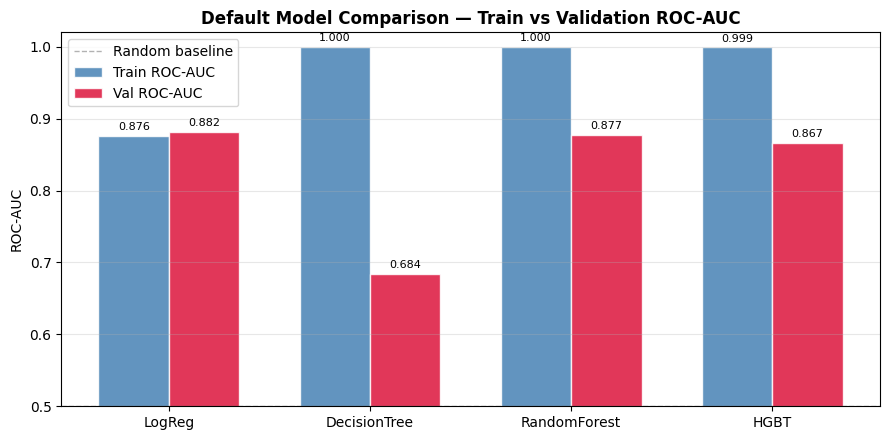

Saved: /tmp/fig_default_model_auc_comparison.png


In [0]:
%python

default_rows = [r for r in results_val if "(default)" in r["model"]]
df_default = pd.DataFrame(default_rows)
df_default = df_default.drop_duplicates(subset=["model"], keep="last")
df_default["model_short"] = df_default["model"].str.replace(" (default)", "", regex=False)

model_names = df_default["model_short"].tolist()

from sklearn.metrics import roc_auc_score

train_aucs = []
val_aucs   = df_default["roc_auc"].tolist()

for name in model_names:
    clf = candidates_default[name]
    tr_prob = clf.predict_proba(X_train_sc)[:, 1]
    train_aucs.append(round(roc_auc_score(y_train, tr_prob), 4))

x      = np.arange(len(model_names))
width  = 0.35

fig, ax = plt.subplots(figsize=(9, 4.5))

bars1 = ax.bar(x - width / 2, train_aucs, width, label="Train ROC-AUC",
               color="steelblue", alpha=0.85, edgecolor="white")
bars2 = ax.bar(x + width / 2, val_aucs,   width, label="Val ROC-AUC",
               color="crimson", alpha=0.85, edgecolor="white")

ax.set_ylabel("ROC-AUC")
ax.set_title("Default Model Comparison — Train vs Validation ROC-AUC", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.5, 1.02)
ax.axhline(0.5, linestyle="--", linewidth=1, color="grey", alpha=0.6, label="Random baseline")
ax.legend()
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()

fig_path = "/tmp/fig_default_model_auc_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

In [0]:
%python
from sklearn.model_selection import ParameterGrid

param_grid_lr = {
    'C'            : [0.01, 0.1, 1.0, 10.0],
    'class_weight' : [None, 'balanced'],    # class_weight='balanced' helps compensate for the churn/non-churn class imbalance
    'penalty'      : ['l2'],}

lr_results = []

for params in ParameterGrid(param_grid_lr):
    clf = LogisticRegression(
        max_iter=2000,
        random_state=SEED,
        **params)

    clf.fit(X_train_sc, y_train)

    vl_prob = clf.predict_proba(X_val_sc)[:, 1]
    vl_pred = clf.predict(X_val_sc)

    lr_results.append({
        **params,
        'val_roc_auc': round(roc_auc_score(y_val, vl_prob), 4),
        'val_f1'     : round(f1_score(y_val, vl_pred, zero_division=0), 4),})

lr_df = pd.DataFrame(lr_results).sort_values('val_roc_auc', ascending=False)

print("LR tuning results (top 8 by val ROC-AUC):")
print(lr_df.head(8).to_string(index=False))

best_lr_row = lr_df.iloc[0]

best_lr_params = {
    'C': float(best_lr_row['C']),
    'class_weight': None if pd.isna(best_lr_row['class_weight']) else best_lr_row['class_weight'],
    'penalty': str(best_lr_row['penalty']),}

print(f"\nBest LR params: {best_lr_params}")
print(f"Best LR val ROC-AUC: {best_lr_row['val_roc_auc']}")

LR tuning results (top 8 by val ROC-AUC):
    C class_weight penalty  val_roc_auc  val_f1
 1.00         None      l2       0.8816  0.6143
 1.00     balanced      l2       0.8815  0.6969
 0.10     balanced      l2       0.8813  0.6904
 0.10         None      l2       0.8810  0.6109
10.00         None      l2       0.8810  0.6174
10.00     balanced      l2       0.8810  0.6966
 0.01     balanced      l2       0.8795  0.6873
 0.01         None      l2       0.8788  0.6024

Best LR params: {'C': 1.0, 'class_weight': None, 'penalty': 'l2'}
Best LR val ROC-AUC: 0.8816


In [0]:
%python

param_grid_rf = {
    'max_depth'        : [5, 10, 15, None],
    'min_samples_leaf' : [5, 10, 20],
    'class_weight'     : [None, 'balanced'],
}

rf_results = []

for params in ParameterGrid(param_grid_rf):
    clf = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1,
        **params
    )

    clf.fit(X_train_sc, y_train)

    vl_prob = clf.predict_proba(X_val_sc)[:, 1]
    vl_pred = clf.predict(X_val_sc)

    tr_prob = clf.predict_proba(X_train_sc)[:, 1]
    tr_auc  = roc_auc_score(y_train, tr_prob)

    rf_results.append({
        **params,
        'val_roc_auc': round(roc_auc_score(y_val, vl_prob), 4),
        'val_f1'     : round(f1_score(y_val, vl_pred, zero_division=0), 4),
        'train_auc'  : round(tr_auc, 4),
    })

rf_df = pd.DataFrame(rf_results).sort_values('val_roc_auc', ascending=False)

print("RF tuning results (top 8 by val ROC-AUC):")
print(rf_df.head(8).to_string(index=False))

best_rf_row = rf_df.iloc[0]

best_rf_params = {
    'max_depth': None if pd.isna(best_rf_row['max_depth']) else int(best_rf_row['max_depth']),
    'min_samples_leaf': int(best_rf_row['min_samples_leaf']),
    'class_weight': None if pd.isna(best_rf_row['class_weight']) else best_rf_row['class_weight'],
}

print(f"\nBest RF params: {best_rf_params}")
print(f"Best RF val ROC-AUC: {best_rf_row['val_roc_auc']}")

RF tuning results (top 8 by val ROC-AUC):
class_weight  max_depth  min_samples_leaf  val_roc_auc  val_f1  train_auc
        None        5.0                20       0.8914  0.6443     0.8959
        None        5.0                 5       0.8909  0.6421     0.9007
        None        5.0                10       0.8908  0.6383     0.8987
        None       10.0                20       0.8905  0.6577     0.9140
        None        NaN                20       0.8904  0.6523     0.9155
        None       15.0                20       0.8904  0.6526     0.9156
    balanced        5.0                20       0.8894  0.7125     0.8953
    balanced       15.0                20       0.8893  0.7089     0.9153

Best RF params: {'max_depth': 5, 'min_samples_leaf': 20, 'class_weight': None}
Best RF val ROC-AUC: 0.8914


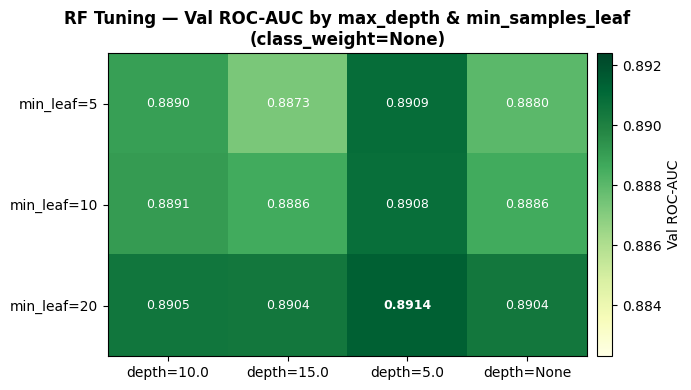

Saved: /tmp/fig_rf_tuning_heatmap.png


In [0]:
%python

rf_plot = rf_df[rf_df["class_weight"].isna()].copy()
rf_plot["max_depth"] = rf_plot["max_depth"].fillna("None").astype(str)

pivot = rf_plot.pivot_table(
    index="min_samples_leaf",
    columns="max_depth",
    values="val_roc_auc",
    aggfunc="max",
)

fig, ax = plt.subplots(figsize=(7, 4))

im = ax.imshow(pivot.values, cmap="YlGn", vmin=pivot.values.min() - 0.005, vmax=pivot.values.max() + 0.001, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_yticks(range(len(pivot.index)))
ax.set_xticklabels([f"depth={c}" for c in pivot.columns])
ax.set_yticklabels([f"min_leaf={r}" for r in pivot.index])
ax.set_title("RF Tuning — Val ROC-AUC by max_depth & min_samples_leaf\n(class_weight=None)", fontweight="bold")

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f"{val:.4f}", ha="center", va="center", fontsize=9,
                color="black" if val < pivot.values.max() - 0.01 else "white",
                fontweight="bold" if val == pivot.values.max() else "normal")

plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02, label="Val ROC-AUC")
plt.tight_layout()

fig_path = "/tmp/fig_rf_tuning_heatmap.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

In [0]:
%python

param_grid_hgbt = {
    'learning_rate'   : [0.05, 0.1, 0.2],
    'max_depth'       : [3, 5, None],
    'min_samples_leaf': [10, 20, 40],
}

hgbt_results = []

for params in ParameterGrid(param_grid_hgbt):
    clf = HistGradientBoostingClassifier(
        max_iter=200,
        random_state=SEED,
        **params)

    clf.fit(X_train_sc, y_train)

    vl_prob = clf.predict_proba(X_val_sc)[:, 1]
    vl_pred = clf.predict(X_val_sc)

    tr_prob = clf.predict_proba(X_train_sc)[:, 1]
    tr_auc  = roc_auc_score(y_train, tr_prob)

    hgbt_results.append({
        **params,
        'val_roc_auc': round(roc_auc_score(y_val, vl_prob), 4),
        'val_f1'     : round(f1_score(y_val, vl_pred, zero_division=0), 4),
        'train_auc'  : round(tr_auc, 4),})

hgbt_df = pd.DataFrame(hgbt_results).sort_values(
    'val_roc_auc',
    ascending=False)

print("HGBT tuning results (top 8 by val ROC-AUC):")
print(hgbt_df.head(8).to_string(index=False))

best_hgbt_row = hgbt_df.iloc[0]

best_hgbt_params = {
    'learning_rate': float(best_hgbt_row['learning_rate']),
    'max_depth': None if pd.isna(best_hgbt_row['max_depth']) else int(best_hgbt_row['max_depth']),
    'min_samples_leaf': int(best_hgbt_row['min_samples_leaf']),}

print(f"\nBest HGBT params: {best_hgbt_params}")
print(f"Best HGBT val ROC-AUC: {best_hgbt_row['val_roc_auc']}")

HGBT tuning results (top 8 by val ROC-AUC):
 learning_rate  max_depth  min_samples_leaf  val_roc_auc  val_f1  train_auc
          0.05        3.0                20       0.8868  0.6749     0.9143
          0.05        3.0                40       0.8860  0.6728     0.9115
          0.05        3.0                10       0.8853  0.6749     0.9163
          0.05        5.0                40       0.8812  0.6640     0.9475
          0.05        5.0                10       0.8800  0.6605     0.9652
          0.05        5.0                20       0.8798  0.6592     0.9578
          0.10        3.0                10       0.8785  0.6596     0.9409
          0.10        3.0                20       0.8782  0.6633     0.9375

Best HGBT params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 20}
Best HGBT val ROC-AUC: 0.8868


In [0]:
%python

best_lr_params = {
    'C': float(best_lr_params['C']),
    'class_weight': None if pd.isna(best_lr_params.get('class_weight')) else best_lr_params.get('class_weight'),
    'penalty': str(best_lr_params.get('penalty', 'l2')),
}

best_rf_params = {
    'max_depth': None if pd.isna(best_rf_params.get('max_depth')) else int(best_rf_params.get('max_depth')),
    'min_samples_leaf': int(best_rf_params.get('min_samples_leaf')),
    'class_weight': None if pd.isna(best_rf_params.get('class_weight')) else best_rf_params.get('class_weight'),
}

best_hgbt_params = {
    'learning_rate': float(best_hgbt_params['learning_rate']),
    'max_depth': None if pd.isna(best_hgbt_params.get('max_depth')) else int(best_hgbt_params.get('max_depth')),
    'min_samples_leaf': int(best_hgbt_params['min_samples_leaf']),
}

print("Best parameter dictionaries used in Cell 45:")
print(f"LR : {best_lr_params}")
print(f"RF : {best_rf_params}")
print(f"HGBT : {best_hgbt_params}")

best_lr = LogisticRegression(
    max_iter=2000,
    random_state=SEED,
    **best_lr_params
)

best_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=SEED,
    n_jobs=-1,
    **best_rf_params
)

best_hgbt = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=SEED,
    **best_hgbt_params
)

tuned_models = {
    'LogReg (tuned)'  : best_lr,
    'RandFor (tuned)' : best_rf,
    'HGBT (tuned)'    : best_hgbt,
}

print(f"\n{'Model':<22} {'Train AUC':>10} {'Val AUC':>9} {'Val F1':>8} "
      f"{'Val Prec':>9} {'Val Rec':>9} {'Gap':>7}")
print("-" * 80)

tuned_val_results = {}

for name, clf in tuned_models.items():
    clf.fit(X_train_sc, y_train)

    tr_prob = clf.predict_proba(X_train_sc)[:, 1]
    vl_prob = clf.predict_proba(X_val_sc)[:, 1]

    tr_pred = clf.predict(X_train_sc)
    vl_pred = clf.predict(X_val_sc)

    tr_auc = roc_auc_score(y_train, tr_prob)
    vl_auc = roc_auc_score(y_val, vl_prob)

    vl_f1  = f1_score(y_val, vl_pred, zero_division=0)
    vl_pre = precision_score(y_val, vl_pred, zero_division=0)
    vl_rec = recall_score(y_val, vl_pred, zero_division=0)

    gap = tr_auc - vl_auc

    tuned_val_results[name] = {
        'clf': clf,
        'vl_auc': vl_auc,
        'vl_f1': vl_f1,
        'vl_pred': vl_pred,
        'vl_prob': vl_prob,
        'gap': gap,}

    results_val.append(
        eval_metrics(
            y_val,
            vl_pred,
            vl_prob,
            label=name))

    print(f"{name:<22} {tr_auc:>10.4f} {vl_auc:>9.4f} {vl_f1:>8.4f} "
          f"{vl_pre:>9.4f} {vl_rec:>9.4f} {gap:>7.4f}")

best_name = max(
    tuned_val_results,
    key=lambda k: tuned_val_results[k]['vl_auc'])

print(f"\nSelected final model: {best_name}")
print(f"Val ROC-AUC = {tuned_val_results[best_name]['vl_auc']:.4f}")
print(f"Val F1 = {tuned_val_results[best_name]['vl_f1']:.4f}")
print(f"Overfit gap = {tuned_val_results[best_name]['gap']:.4f}")

Best parameter dictionaries used in Cell 45:
LR : {'C': 1.0, 'class_weight': None, 'penalty': 'l2'}
RF : {'max_depth': 5, 'min_samples_leaf': 20, 'class_weight': None}
HGBT : {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 20}

Model                   Train AUC   Val AUC   Val F1  Val Prec   Val Rec     Gap
--------------------------------------------------------------------------------
LogReg (tuned)             0.8760    0.8816   0.6143    0.7590    0.5160 -0.0056
RandFor (tuned)            0.8959    0.8914   0.6443    0.7741    0.5518  0.0046
HGBT (tuned)               0.9143    0.8868   0.6749    0.7494    0.6139  0.0275

Selected final model: RandFor (tuned)
Val ROC-AUC = 0.8914
Val F1 = 0.6443
Overfit gap = 0.0046


## Permutation Importance

In [0]:
%python

from sklearn.inspection import permutation_importance

best_clf = tuned_val_results[best_name]['clf']

# Permutation importance measures how much validation ROC-AUC drops when each feature is shuffled
pi = permutation_importance(best_clf, X_val_sc, y_val,
    n_repeats=10,
    scoring='roc_auc',
    random_state=SEED
)

pi_df = pd.DataFrame({
    'feature'        : FINAL_FEATURE_COLS,
    'importance_mean': pi.importances_mean,
    'importance_std' : pi.importances_std,
}).sort_values('importance_mean', ascending=False)

print("Permutation importance on VALIDATION set (top 20):")
print(f"{'Feature':<35} {'Mean Imp':>10} {'Std':>8}")
print("-" * 56)

for _, row in pi_df.head(20).iterrows():
    bar = '█' * max(0, int(row.importance_mean * 500))
    print(f"{row.feature:<35} {row.importance_mean:>10.5f} ±{row.importance_std:>7.5f}  {bar}")

DROP_THRESHOLD = -0.001

features_to_drop = pi_df[pi_df.importance_mean < DROP_THRESHOLD]['feature'].tolist()
features_to_keep = pi_df[pi_df.importance_mean >= DROP_THRESHOLD]['feature'].tolist()

print(f"\nFeatures dropped (importance < {DROP_THRESHOLD}): {features_to_drop}")
print(f"Features retained: {len(features_to_keep)}")

Permutation importance on VALIDATION set (top 20):
Feature                               Mean Imp      Std
--------------------------------------------------------
total_visits_lifetime                  0.03131 ±0.00300  ███████████████
total_spend_lifetime                   0.01126 ±0.00190  █████
avg_gap_lifetime                       0.00772 ±0.00125  ███
customer_tenure_days                   0.00373 ±0.00115  █
spend_ratio_w1w2                       0.00124 ±0.00039  
days_since_last_purchase               0.00121 ±0.00032  
visits_w1                              0.00053 ±0.00039  
qty_w4                                 0.00042 ±0.00037  
spend_w1                               0.00034 ±0.00010  
spend_w4                               0.00031 ±0.00027  
qty_w1                                 0.00029 ±0.00012  
visits_w4                              0.00018 ±0.00024  
spend_trend_w1w3                       0.00013 ±0.00004  
visits_w2                              0.00012 ±0.00016  


In [0]:
%python

X_train_sel = X_train_f[features_to_keep]
X_val_sel   = X_val_f[features_to_keep]
X_test_sel  = X_test_f[features_to_keep]

TEMPORAL_GROUPS_SEL = {
    group_name: [c for c in cols if c in X_train_sel.columns]
    for group_name, cols in TEMPORAL_GROUPS.items()}

TEMPORAL_GROUPS_SEL = {
    group_name: cols
    for group_name, cols in TEMPORAL_GROUPS_SEL.items()
    if len(cols) >= 2}

scaler_sel_params = fit_temporal_group_scaler(X_train_sel, TEMPORAL_GROUPS_SEL)

X_train_sel_sc_df = apply_temporal_group_scaler(X_train_sel, scaler_sel_params)
X_val_sel_sc_df = apply_temporal_group_scaler(X_val_sel, scaler_sel_params)
X_test_sel_sc_df = apply_temporal_group_scaler(X_test_sel, scaler_sel_params)

X_train_sel_sc = X_train_sel_sc_df.to_numpy()
X_val_sel_sc = X_val_sel_sc_df.to_numpy()
X_test_sel_sc = X_test_sel_sc_df.to_numpy()

if 'HGBT' in best_name:
    final_clf_sel = HistGradientBoostingClassifier(
        max_iter=200,
        random_state=SEED,
        **best_hgbt_params
    )
elif 'RandFor' in best_name:
    final_clf_sel = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1,
        **best_rf_params
    )
else:
    final_clf_sel = LogisticRegression(
        max_iter=2000,
        random_state=SEED,
        **best_lr_params
    )

final_clf_sel.fit(X_train_sel_sc, y_train)

vl_prob_sel = final_clf_sel.predict_proba(X_val_sel_sc)[:, 1]
vl_pred_sel = final_clf_sel.predict(X_val_sel_sc)

auc_full_feat = tuned_val_results[best_name]['vl_auc']
auc_sel_feat = roc_auc_score(y_val, vl_prob_sel)
f1_sel_feat = f1_score(y_val, vl_pred_sel, zero_division=0)
auc_loss = auc_full_feat - auc_sel_feat

print(f"Val ROC-AUC — all features: {auc_full_feat:.4f}")
print(f"Val ROC-AUC — selected features: {auc_sel_feat:.4f} "
      f"({'better' if auc_sel_feat >= auc_full_feat else 'worse'})")
print(f"Val ROC-AUC loss from feature selection: {auc_loss:.4f}")
print(f"Val F1 — selected features: {f1_sel_feat:.4f}")
print(f"Features used: {len(features_to_keep)}")

USE_SELECTED = auc_loss <= 0.002

if USE_SELECTED:
    print("\nSelected-feature model adopted because AUC loss is within 0.002 tolerance.")
    FINAL_FEATURES = features_to_keep
    X_train_final_sc, X_val_final_sc, X_test_final_sc = (
        X_train_sel_sc,
        X_val_sel_sc,
        X_test_sel_sc
    )
    scaler_final = scaler_sel_params
else:
    print("\nFull-feature model retained because AUC loss is greater than 0.002.")
    FINAL_FEATURES = FINAL_FEATURE_COLS
    X_train_final_sc, X_val_final_sc, X_test_final_sc = (
        X_train_sc,
        X_val_sc,
        X_test_sc
    )
    scaler_final = scaler_params

Val ROC-AUC — all features: 0.8914
Val ROC-AUC — selected features: 0.8910 (worse)
Val ROC-AUC loss from feature selection: 0.0004
Val F1 — selected features: 0.6432
Features used: 30

Selected-feature model adopted because AUC loss is within 0.002 tolerance.


## Final Test Evaluation

In [0]:
%python

from sklearn.metrics import confusion_matrix
import numpy as np

X_trainval = np.vstack([X_train_final_sc, X_val_final_sc])
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

if 'HGBT' in best_name:
    final_model = HistGradientBoostingClassifier(
        max_iter=200,
        random_state=SEED,
        **best_hgbt_params
    )
elif 'RandFor' in best_name:
    final_model = RandomForestClassifier(
        n_estimators=200,
        random_state=SEED,
        n_jobs=-1,
        **best_rf_params
    )
else:
    final_model = LogisticRegression(
        max_iter=2000,
        random_state=SEED,
        **best_lr_params
    )

final_model.fit(X_trainval, y_trainval)

test_prob = final_model.predict_proba(X_test_final_sc)[:, 1]
test_pred = final_model.predict(X_test_final_sc)

test_auc = roc_auc_score(y_test, test_prob)
test_f1  = f1_score(y_test, test_pred, zero_division=0)
test_pre = precision_score(y_test, test_pred, zero_division=0)
test_rec = recall_score(y_test, test_pred, zero_division=0)
test_acc = accuracy_score(y_test, test_pred)
test_cm  = confusion_matrix(y_test, test_pred)

print("=" * 60)
print(f"  FINAL OUT-OF-TIME TEST RESULTS  (R_TEST = {R_TEST})")
print("=" * 60)
print(f"Model : {best_name}")
print(f"Test ROC-AUC : {test_auc:.4f}")
print(f"Test F1 (churn) : {test_f1:.4f}")
print(f"Test Precision : {test_pre:.4f}")
print(f"Test Recall : {test_rec:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print()
print("Confusion Matrix (rows=actual, cols=predicted):")
print(f"Pred Non-churn  Pred Churn")
print(f"Actual Non-churn [{test_cm[0,0]:>12,}  {test_cm[0,1]:>10,}]")
print(f"Actual Churn [{test_cm[1,0]:>12,}  {test_cm[1,1]:>10,}]")

  FINAL OUT-OF-TIME TEST RESULTS  (R_TEST = 500)
Model : RandFor (tuned)
Test ROC-AUC : 0.8721
Test F1 (churn) : 0.5617
Test Precision : 0.7514
Test Recall : 0.4485
Test Accuracy : 0.8083

Confusion Matrix (rows=actual, cols=predicted):
Pred Non-churn  Pred Churn
Actual Non-churn [       2,309         137]
Actual Churn [         509         414]


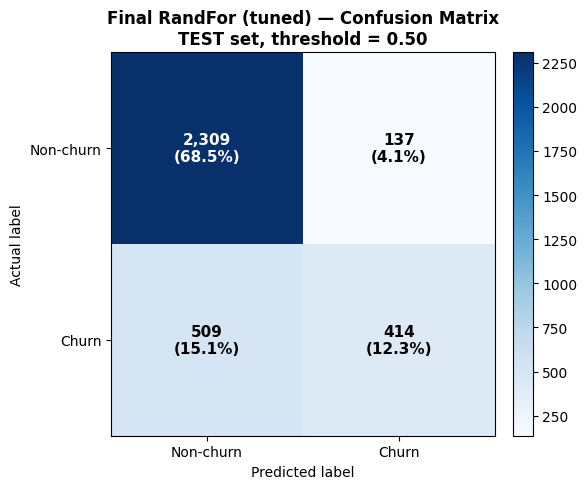

Saved: /tmp/fig_confusion_matrix.png
Rows = actual, columns = predicted


In [0]:
%python

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(test_cm, cmap="Blues")

ax.set_title(f"Final {best_name} — Confusion Matrix\nTEST set, threshold = 0.50", fontweight="bold")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-churn", "Churn"])
ax.set_yticklabels(["Non-churn", "Churn"])

total = test_cm.sum()

for i in range(test_cm.shape[0]):
    for j in range(test_cm.shape[1]):
        count = test_cm[i, j]
        pct = 100 * count / total
        ax.text(j,i,
            f"{count:,}\n({pct:.1f}%)",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color="white" if count > test_cm.max() / 2 else "black"
        )

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()

fig_path = "/tmp/fig_confusion_matrix.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")
print("Rows = actual, columns = predicted")

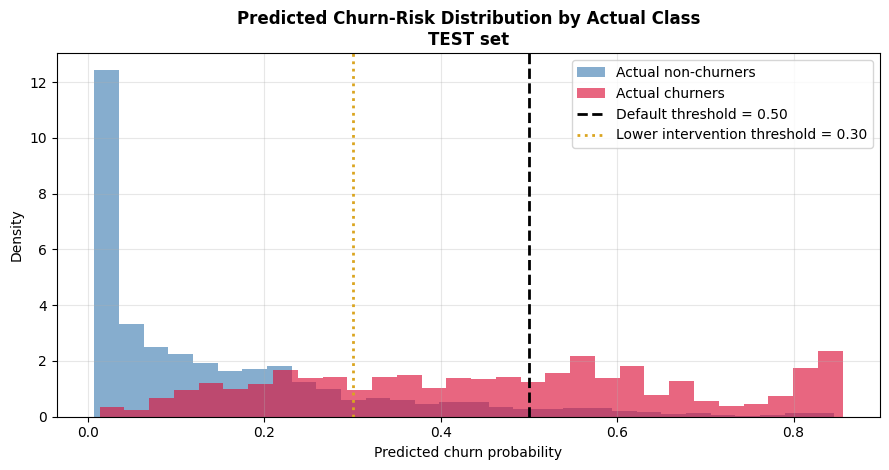

Saved: /tmp/fig_predicted_risk_distribution.png
Mean predicted risk — actual churners: 0.461
Mean predicted risk — non-churners: 0.149


In [0]:
%python

risk_df = pd.DataFrame({
    "actual_churn": y_test.values,
    "predicted_risk": test_prob})

fig, ax = plt.subplots(figsize=(9, 4.8))

ax.hist(risk_df[risk_df["actual_churn"] == 0]["predicted_risk"],
    bins=30,
    color="steelblue",
    alpha=0.65,
    label="Actual non-churners",
    density=True)

ax.hist(risk_df[risk_df["actual_churn"] == 1]["predicted_risk"],
    bins=30,
    color="crimson",
    alpha=0.65,
    label="Actual churners",
    density=True)

ax.axvline(0.50,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Default threshold = 0.50")

ax.axvline(0.30,
    color="goldenrod",
    linestyle=":",
    linewidth=2,
    label="Lower intervention threshold = 0.30")

ax.set_title("Predicted Churn-Risk Distribution by Actual Class\nTEST set", fontweight="bold")
ax.set_xlabel("Predicted churn probability")
ax.set_ylabel("Density")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()

fig_path = "/tmp/fig_predicted_risk_distribution.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")
print(f"Mean predicted risk — actual churners: {risk_df[risk_df.actual_churn == 1]['predicted_risk'].mean():.3f}")
print(f"Mean predicted risk — non-churners: {risk_df[risk_df.actual_churn == 0]['predicted_risk'].mean():.3f}")

In [0]:
%python

final_test_row = {
    'model': f'{best_name} — FINAL TEST',
    'accuracy': round(test_acc, 4),
    'precision': round(test_pre, 4),
    'recall': round(test_rec, 4),
    'f1': round(test_f1, 4),
    'roc_auc': round(test_auc, 4),}

all_results = pd.DataFrame(results_val + [final_test_row])
all_results = all_results.drop_duplicates(subset=["model"], keep="last")
all_results = all_results.set_index('model')

print("COMPLETE MODEL COMPARISON TABLE")
print("All rows = validation set performance, except final row = test set")
print()
print(all_results.to_string())

COMPLETE MODEL COMPARISON TABLE
All rows = validation set performance, except final row = test set

                              accuracy  precision  recall      f1  roc_auc
model                                                                     
Baseline: all non-churn         0.7083     0.0000  0.0000  0.0000   0.5000
Baseline: recency > 7 days      0.6202     0.4220  0.8173  0.5566   0.7283
LogReg (default)                0.8110     0.7590  0.5160  0.6143   0.8816
DecisionTree (default)          0.7245     0.5248  0.5885  0.5548   0.6845
RandomForest (default)          0.8110     0.7205  0.5753  0.6398   0.8773
HGBT (default)                  0.7987     0.6737  0.6008  0.6351   0.8668
LogReg (tuned)                  0.8110     0.7590  0.5160  0.6143   0.8816
RandFor (tuned)                 0.8223     0.7741  0.5518  0.6443   0.8914
HGBT (tuned)                    0.8275     0.7494  0.6139  0.6749   0.8868
RandFor (tuned) — FINAL TEST    0.8083     0.7514  0.4485  0.5617   0.8721


In [0]:
%python
from sklearn.metrics import precision_recall_curve, roc_curve

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_test, test_prob)

threshold_df = pd.DataFrame({
    'threshold': thresh_arr,
    'precision': prec_arr[:-1],
    'recall': rec_arr[:-1],
    'f1': 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-9),}).round(4)

print("Precision / Recall trade-off at selected thresholds (TEST SET):")
print(f"\n{'Threshold':>11} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Flagged as churn':>18}")
print("-" * 60)

for t in [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]:
    preds_t = (test_prob >= t).astype(int)
    pre_t = precision_score(y_test, preds_t, zero_division=0)
    rec_t = recall_score(y_test, preds_t, zero_division=0)
    f1_t = f1_score(y_test, preds_t, zero_division=0)
    flagged = preds_t.sum()

    print(f"{t:>11.2f} {pre_t:>10.4f} {rec_t:>8.4f} {f1_t:>8.4f} {flagged:>18,}")

Precision / Recall trade-off at selected thresholds (TEST SET):

  Threshold  Precision   Recall       F1   Flagged as churn
------------------------------------------------------------
       0.20     0.5349   0.8635   0.6606              1,490
       0.30     0.6279   0.7075   0.6653              1,040
       0.40     0.6892   0.5861   0.6335                785
       0.50     0.7514   0.4485   0.5617                551
       0.60     0.7898   0.2849   0.4188                333
       0.70     0.8352   0.1647   0.2751                182


In [0]:
%python

val_results_df = pd.DataFrame(results_val)

val_results_df = (
    val_results_df
    .drop_duplicates(subset=["model"], keep="last")
    .copy())

val_results_df["split"] = "Val"

val_results_df = val_results_df.rename(columns={
    "model": "Model",
    "accuracy": "Acc",
    "precision": "Prec",
    "recall": "Rec",
    "f1": "F1",
    "roc_auc": "ROC-AUC",})

final_test_row = pd.DataFrame([{
    "Model": f"{best_name} — FINAL TEST",
    "Acc": round(test_acc, 4),
    "Prec": round(test_pre, 4),
    "Rec": round(test_rec, 4),
    "F1": round(test_f1, 4),
    "ROC-AUC": round(test_auc, 4),
    "split": "TEST",}])

report_table = pd.concat(
    [val_results_df[["Model", "split", "Acc", "Prec", "Rec", "F1", "ROC-AUC"]],
    final_test_row[["Model", "split", "Acc", "Prec", "Rec", "F1", "ROC-AUC"]]],
    ignore_index=True)

print("CLEAN MODEL COMPARISON TABLE — REPORT VERSION")
print("=" * 90)
print(f"{'Model':<45} {'Split':>6} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'AUC':>8}")
print("-" * 90)

for _, r in report_table.iterrows():
    marker = " ← final reported performance" if r["split"] == "TEST" else ""
    print(f"{r['Model']:<45} "
        f"{r['split']:>6} "
        f"{r['Acc']:>7.3f} "
        f"{r['Prec']:>7.3f} "
        f"{r['Rec']:>7.3f} "
        f"{r['F1']:>7.3f} "
        f"{r['ROC-AUC']:>8.3f}"
        f"{marker}")

CLEAN MODEL COMPARISON TABLE — REPORT VERSION
Model                                          Split     Acc    Prec     Rec      F1      AUC
------------------------------------------------------------------------------------------
Baseline: all non-churn                          Val   0.708   0.000   0.000   0.000    0.500
Baseline: recency > 7 days                       Val   0.620   0.422   0.817   0.557    0.728
LogReg (default)                                 Val   0.811   0.759   0.516   0.614    0.882
DecisionTree (default)                           Val   0.725   0.525   0.589   0.555    0.684
RandomForest (default)                           Val   0.811   0.721   0.575   0.640    0.877
HGBT (default)                                   Val   0.799   0.674   0.601   0.635    0.867
LogReg (tuned)                                   Val   0.811   0.759   0.516   0.614    0.882
RandFor (tuned)                                  Val   0.822   0.774   0.552   0.644    0.891
HGBT (tuned)     

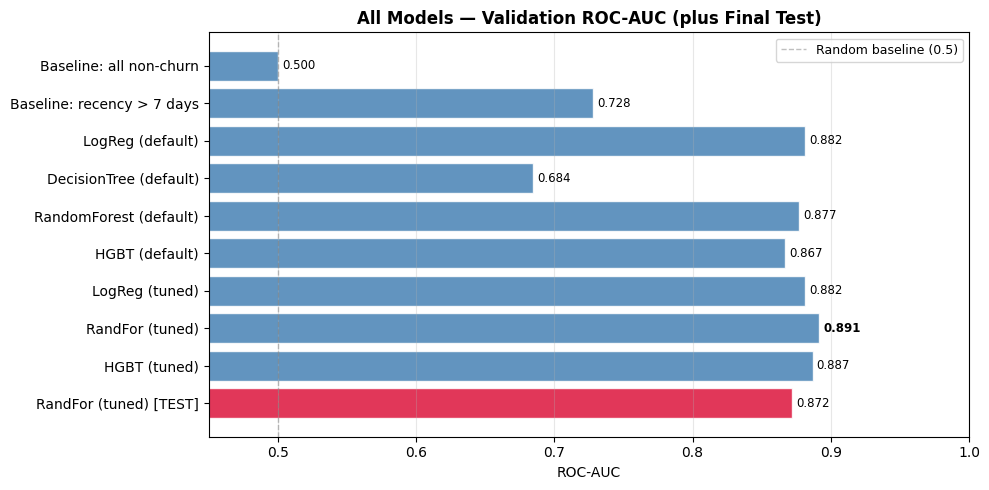

Saved: /tmp/fig_all_models_roc_auc.png


In [0]:
%python

plot_df = report_table.copy()
colors = ["crimson" if "FINAL TEST" in str(m) else "steelblue" for m in plot_df["Model"]]

plot_df["Model_short"] = (plot_df["Model"].str.replace("* ", "", regex=False).str.replace(" — FINAL TEST", " [TEST]", regex=False))
fig, ax = plt.subplots(figsize=(10, max(5, len(plot_df) * 0.45)))
bars = ax.barh(plot_df["Model_short"], plot_df["ROC-AUC"],
    color=colors,
    alpha=0.85,
    edgecolor="white",)

ax.set_xlabel("ROC-AUC")
ax.set_title("All Models — Validation ROC-AUC (plus Final Test)", fontweight="bold")
ax.set_xlim(0.45, 1.0)
ax.axvline(0.5, linestyle="--", linewidth=1, color="grey", alpha=0.5, label="Random baseline (0.5)")
ax.legend(fontsize=9)
ax.grid(axis="x", alpha=0.3)
ax.invert_yaxis()

for bar, val in zip(bars, plot_df["ROC-AUC"]):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=8.5,
        fontweight="bold" if val == plot_df["ROC-AUC"].max() else "normal",)

plt.tight_layout()

fig_path = "/tmp/fig_all_models_roc_auc.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

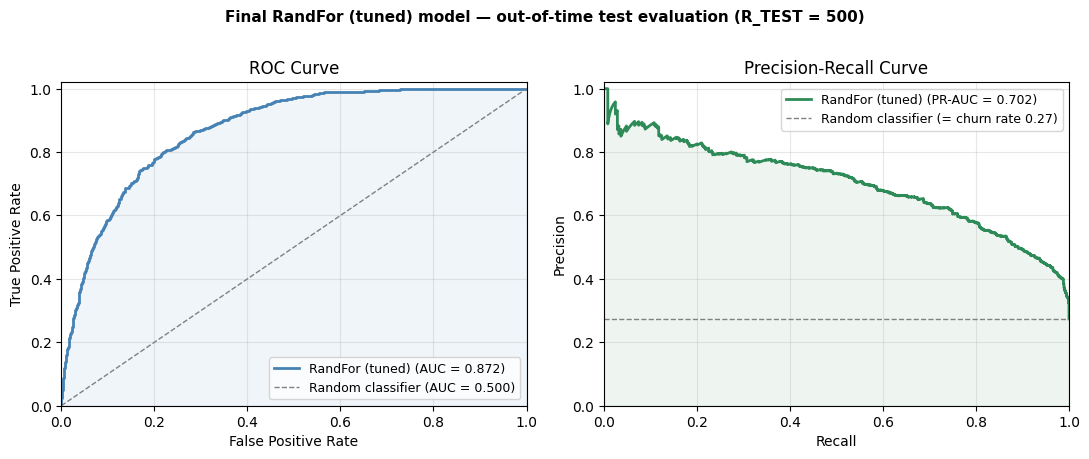

Saved: /tmp/fig_roc_pr_curves.png
ROC-AUC = 0.8721  |  PR-AUC = 0.7017
Random PR baseline/churn rate = 0.2740


In [0]:
%python

from sklearn.metrics import auc, precision_recall_curve, precision_score, recall_score, roc_curve, roc_auc_score, f1_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

fpr, tpr, _ = roc_curve(y_test, test_prob)
prec_c, rec_c, _ = precision_recall_curve(y_test, test_prob)

roc_auc_val = auc(fpr, tpr)
pr_auc_val  = auc(rec_c, prec_c)
random_prec = y_test.mean()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

fig.suptitle(f"Final {best_name} model — out-of-time test evaluation (R_TEST = 500)",
    fontsize=11,
    fontweight="bold",
    y=1.01)

ax1.plot(fpr, tpr, color="steelblue", lw=2, label=f"{best_name} (AUC = {roc_auc_val:.3f})")
ax1.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random classifier (AUC = 0.500)")
ax1.fill_between(fpr, tpr, alpha=0.08, color="steelblue")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve")
ax1.legend(fontsize=9, loc="lower right")
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1.02])
ax1.grid(True, alpha=0.3)

ax2.plot(rec_c, prec_c, color="seagreen", lw=2, label=f"{best_name} (PR-AUC = {pr_auc_val:.3f})")
ax2.axhline(y=random_prec, color="grey", lw=1, linestyle="--", label=f"Random classifier (= churn rate {random_prec:.2f})")
ax2.fill_between(rec_c, prec_c, alpha=0.08, color="seagreen")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve")
ax2.legend(fontsize=9, loc="upper right")
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.02])
ax2.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = "/tmp/fig_roc_pr_curves.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")
print(f"ROC-AUC = {roc_auc_val:.4f}  |  PR-AUC = {pr_auc_val:.4f}")
print(f"Random PR baseline/churn rate = {random_prec:.4f}")

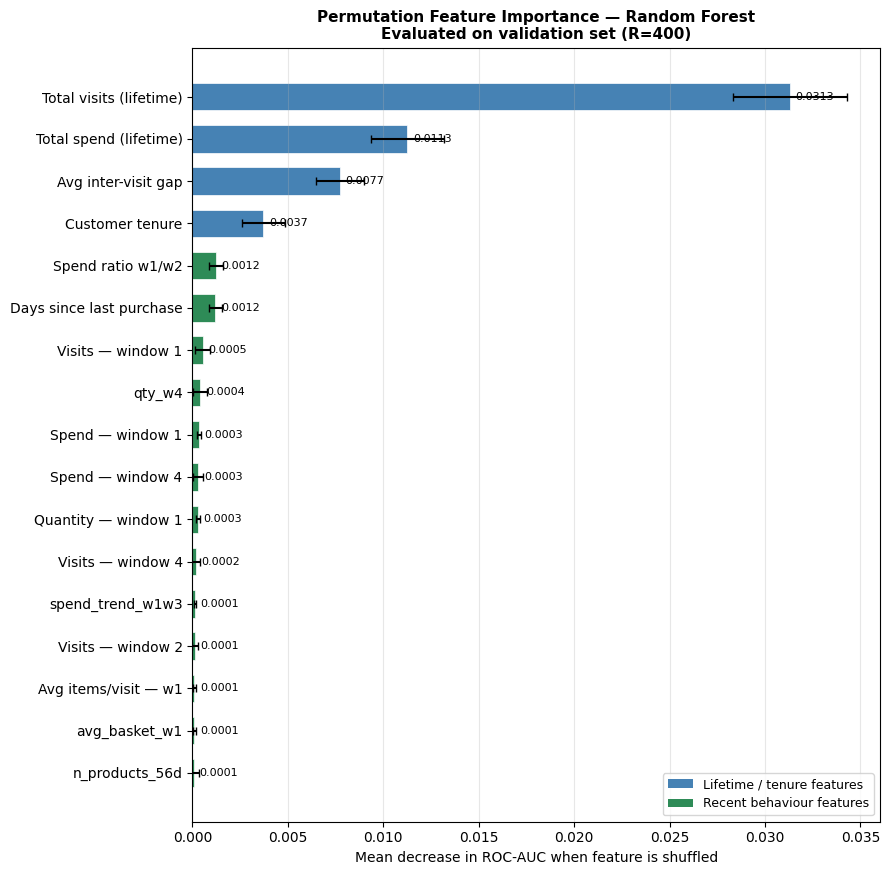

Saved: /tmp/fig_permutation_importance.png
Top feature: total_visits_lifetime | importance = 0.03131


In [0]:
%python

from matplotlib.patches import Patch

plot_pi = pi_df[pi_df["importance_mean"] > 0.00005].copy()

if len(plot_pi) < 5:
    plot_pi = pi_df.sort_values("importance_mean", ascending=False).head(15).copy()

plot_pi = plot_pi.sort_values("importance_mean", ascending=True)

label_map = {
    "total_visits_lifetime": "Total visits (lifetime)",
    "total_spend_lifetime": "Total spend (lifetime)",
    "avg_gap_lifetime": "Avg inter-visit gap",
    "customer_tenure_days": "Customer tenure",
    "days_since_last_purchase": "Days since last purchase",
    "spend_ratio_w1w2": "Spend ratio w1/w2",
    "spend_w4": "Spend — window 4",
    "visits_w4": "Visits — window 4",
    "visits_w1": "Visits — window 1",
    "spend_w1": "Spend — window 1",
    "qty_w1": "Quantity — window 1",
    "qty_w2": "Quantity — window 2",
    "avg_items_per_visit_w1": "Avg items/visit — w1",
    "visits_w2": "Visits — window 2",
    "spend_trend_w1w2": "Spend trend w1-w2",
    "avg_basket_w2": "Avg basket value — w2",
    "n_stores_56d": "Distinct stores",
    "spend_w2": "Spend — window 2",}

plot_pi["label"] = plot_pi["feature"].map(label_map).fillna(plot_pi["feature"])

lifetime_feats = {
    "total_visits_lifetime",
    "total_spend_lifetime",
    "avg_gap_lifetime",
    "customer_tenure_days",}

colours = [
    "steelblue" if f in lifetime_feats else "seagreen"
    for f in plot_pi["feature"]]

fig_height = max(5, 0.45 * len(plot_pi) + 1.2)
fig, ax = plt.subplots(figsize=(9, fig_height))

bars = ax.barh(
    plot_pi["label"],
    plot_pi["importance_mean"],
    xerr=plot_pi["importance_std"],
    color=colours,
    capsize=3,
    height=0.65,
    edgecolor="white",
    linewidth=0.5)

ax.set_xlabel("Mean decrease in ROC-AUC when feature is shuffled")
ax.set_title(
    "Permutation Feature Importance — Random Forest\n"
    "Evaluated on validation set (R=400)",
    fontsize=11,
    fontweight="bold")

for bar, val in zip(bars, plot_pi["importance_mean"]):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height() / 2,
        f"{val:.4f}",
        va="center",
        fontsize=8)

legend_elements = [
    Patch(facecolor="steelblue", label="Lifetime / tenure features"),
    Patch(facecolor="seagreen", label="Recent behaviour features"),]

ax.legend(handles=legend_elements, fontsize=9, loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.set_xlim(left=0)

plt.tight_layout()

fig_path = "/tmp/fig_permutation_importance.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

top_feature = pi_df.sort_values("importance_mean", ascending=False).iloc[0]
print(f"Top feature: {top_feature['feature']} | importance = {top_feature['importance_mean']:.5f}")

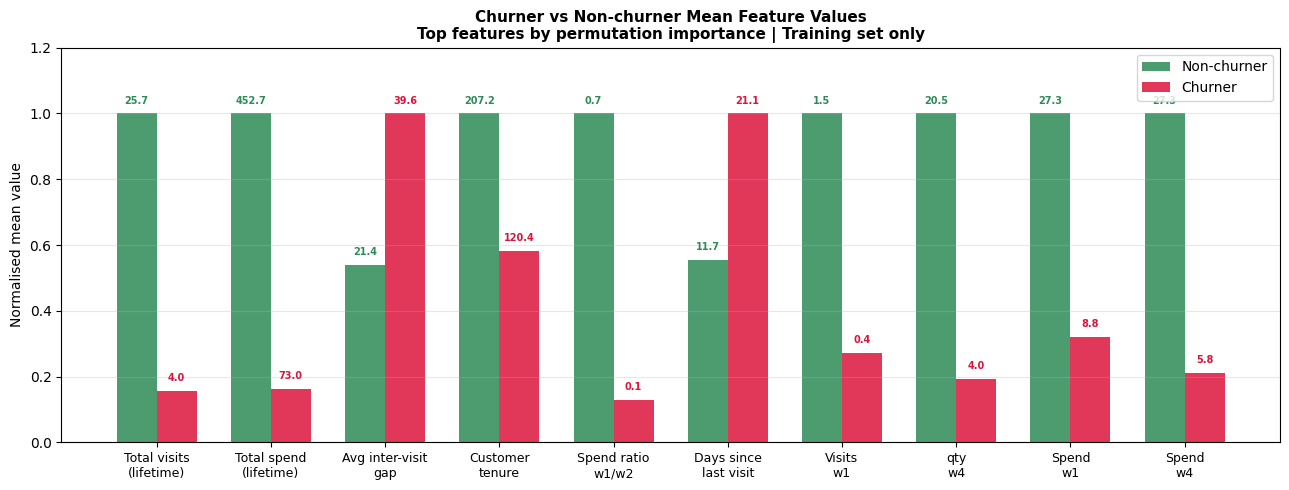

Saved: /tmp/fig_churner_comparison.png

Top features plotted:
  - total_visits_lifetime
  - total_spend_lifetime
  - avg_gap_lifetime
  - customer_tenure_days
  - spend_ratio_w1w2
  - days_since_last_purchase
  - visits_w1
  - qty_w4
  - spend_w1
  - spend_w4


In [0]:
%python

top_feats = (
    pi_df[pi_df["importance_mean"] > 0.0001]
    .sort_values("importance_mean", ascending=False)
    .head(10)["feature"]
    .tolist()
)

if len(top_feats) < 5:
    top_feats = (
        pi_df.sort_values("importance_mean", ascending=False)
        .head(10)["feature"]
        .tolist()
    )

X_train_plot = X_train_f[top_feats].copy()

for col in top_feats:
    X_train_plot[col] = pd.to_numeric(X_train_plot[col], errors="coerce").astype(float)

X_train_plot = X_train_plot.fillna(0)

churn_means = X_train_plot[y_train == 1].mean()
non_churn_means = X_train_plot[y_train == 0].mean()

max_val = pd.concat([churn_means.abs(), non_churn_means.abs()], axis=1).max(axis=1)
max_val = max_val.replace(0, 1)

churn_n = churn_means / max_val
non_churn_n = non_churn_means / max_val

feat_labels = {
    "total_visits_lifetime": "Total visits\n(lifetime)",
    "total_spend_lifetime": "Total spend\n(lifetime)",
    "avg_gap_lifetime": "Avg inter-visit\ngap",
    "customer_tenure_days": "Customer\ntenure",
    "days_since_last_purchase": "Days since\nlast visit",
    "spend_ratio_w1w2": "Spend ratio\nw1/w2",
    "spend_w4": "Spend\nw4",
    "visits_w4": "Visits\nw4",
    "visits_w1": "Visits\nw1",
    "spend_w1": "Spend\nw1",
    "qty_w1": "Quantity\nw1",
    "qty_w2": "Quantity\nw2",
    "n_products_56d": "Distinct\nproducts",
    "n_categories_56d": "Distinct\ncategories",
}

labels = [feat_labels.get(f, f.replace("_", "\n")) for f in top_feats]

x = np.arange(len(top_feats))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))

ax.bar(x - width / 2, non_churn_n.values, width,
    label="Non-churner",
    color="seagreen",
    alpha=0.85
)

ax.bar(x + width / 2, churn_n.values, width,
    label="Churner",
    color="crimson",
    alpha=0.85
)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Normalised mean value")
ax.set_title(
    "Churner vs Non-churner Mean Feature Values\n"
    "Top features by permutation importance | Training set only",
    fontsize=11,
    fontweight="bold"
)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(1.15, float(max(churn_n.max(), non_churn_n.max())) + 0.2))

for i, feat in enumerate(top_feats):
    nc_val = non_churn_means.loc[feat]
    c_val = churn_means.loc[feat]

    ax.text(i - width / 2, non_churn_n.loc[feat] + 0.03, f"{nc_val:.1f}",
        ha="center",
        fontsize=7,
        fontweight="bold",
        color="seagreen"
    )

    ax.text(i + width / 2, churn_n.loc[feat] + 0.03, f"{c_val:.1f}",
        ha="center",
        fontsize=7,
        fontweight="bold",
        color="crimson"
    )

plt.tight_layout()

fig_path = "/tmp/fig_churner_comparison.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")
print("\nTop features plotted:")
for feat in top_feats:
    print(f"  - {feat}")

## Pen Portraits
Pen portraits summarise the *typical* churner and non-churner profiles based on median feature
values from the training set.

In [0]:
%python

# pen portraits compare typical churners and non-churners using median feature values
# Medians are preferred because spend and visit-count features are strongly right-skewed
key_features = [
    'total_visits_lifetime', 'total_spend_lifetime', 'avg_gap_lifetime',
    'customer_tenure_days', 'days_since_last_purchase',
    'visits_w1', 'visits_w2', 'spend_w1', 'spend_w2',
    'spend_ratio_w1w2', 'n_products_56d', 'n_categories_56d',
    'n_stores_56d', 'avg_basket_w1',
]

feat_readable = {
    'total_visits_lifetime': 'Total lifetime visits',
    'total_spend_lifetime': 'Total lifetime spend (£)',
    'avg_gap_lifetime': 'Avg inter-visit gap (days)',
    'customer_tenure_days': 'Customer tenure (days)',
    'days_since_last_purchase' : 'Days since last visit',
    'visits_w1': 'Visits in last 14 days',
    'visits_w2': 'Visits in prior 14 days (w2)',
    'spend_w1': 'Spend in last 14 days (£)',
    'spend_w2': 'Spend in prior 14 days (£)',
    'spend_ratio_w1w2': 'Spend ratio w1/w2',
    'n_products_56d': 'Distinct products (56d)',
    'n_categories_56d': 'Distinct categories (56d)',
    'n_stores_56d': 'Distinct stores (56d)',
    'avg_basket_w1': 'Avg basket value w1 (£)',
}

train_df = X_train_f[key_features].copy()
train_df['churn'] = y_train.values

portrait_rows = []
for feat in key_features:
    nc = train_df[train_df.churn == 0][feat]
    c  = train_df[train_df.churn == 1][feat]

    portrait_rows.append({
        'Feature': feat_readable.get(feat, feat),
        'Non-churn Mean': round(nc.mean(), 2),
        'Non-churn Median': round(nc.median(), 2),
        'Churn Mean': round(c.mean(), 2),
        'Churn Median': round(c.median(), 2),
        'Diff %': round(100 * (c.mean() - nc.mean()) / (nc.mean() + 1e-9), 1),
    })

portrait_df = pd.DataFrame(portrait_rows)

print("PEN PORTRAIT SUMMARY TABLE — TRAINING SET (R=300)")
print("=" * 90)
print(portrait_df.to_string(index=False))

print("\n" + "=" * 70)
print("  TYPICAL CHURNER PROFILE (median values, training set)")
print("=" * 70)

for _, row in portrait_df.iterrows():
    print(f"  {row['Feature']:<38} {row['Churn Median']:>10}")

print("\n" + "=" * 70)
print("  TYPICAL NON-CHURNER PROFILE (median values, training set)")
print("=" * 70)

for _, row in portrait_df.iterrows():
    print(f"  {row['Feature']:<38} {row['Non-churn Median']:>10}")

PEN PORTRAIT SUMMARY TABLE — TRAINING SET (R=300)
                     Feature  Non-churn Mean  Non-churn Median  Churn Mean  Churn Median  Diff %
       Total lifetime visits           25.69             15.00        4.03          2.00   -84.3
    Total lifetime spend (£)          452.65            261.85       73.00         40.45   -83.9
  Avg inter-visit gap (days)           21.38             12.23       39.64         23.25    85.4
      Customer tenure (days)          207.16            207.00      120.37        113.00   -41.9
       Days since last visit           11.69              7.00       21.10         19.00    80.6
      Visits in last 14 days            1.53              1.00        0.42          0.00   -72.9
Visits in prior 14 days (w2)            1.59              1.00        0.41          0.00   -74.4
   Spend in last 14 days (£)           27.30             14.05        8.77          0.00   -67.9
  Spend in prior 14 days (£)           29.18             15.23        8.59   

## Threshold Analysis

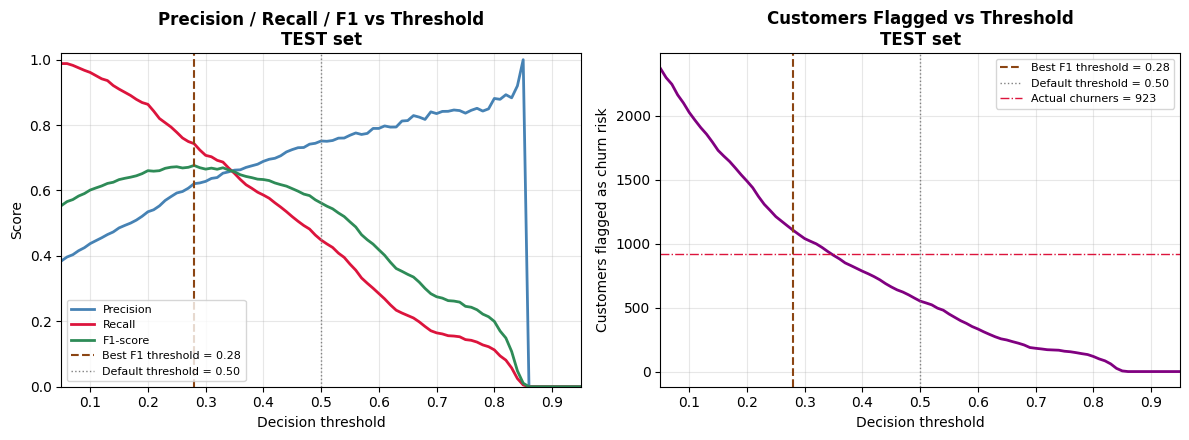

Saved: /tmp/fig_threshold_analysis.png

Threshold comparison on TEST set
   Threshold  Precision     Recall         F1    Flagged  Flagged %
---------------------------------------------------------------------------
        0.30      0.628      0.707      0.665      1,040      30.9%
        0.50      0.751      0.449      0.562        551      16.4%
     Best F1      0.621      0.743      0.677      1,105      32.8%


In [0]:
%python

# sweep probability thresholds to show the trade-off between precision, recall and flagged customers
# the final threshold should be chosen based on business intervention cost, not just default 0.50
thresholds = np.arange(0.05, 0.96, 0.01)

rows = []

for t in thresholds:
    preds_t = (test_prob >= t).astype(int)

    rows.append({
        "threshold": round(float(t), 2),
        "precision": precision_score(y_test, preds_t, zero_division=0),
        "recall": recall_score(y_test, preds_t, zero_division=0),
        "f1": f1_score(y_test, preds_t, zero_division=0),
        "flagged": int(preds_t.sum()),
        "flagged_pct": 100 * preds_t.sum() / len(preds_t),})

threshold_results = pd.DataFrame(rows)

best_threshold_row = threshold_results.sort_values("f1", ascending=False).iloc[0]
recommended_threshold = float(best_threshold_row["threshold"])

row_030 = threshold_results.iloc[(threshold_results["threshold"] - 0.30).abs().argsort()[:1]].iloc[0]

row_050 = threshold_results.iloc[(threshold_results["threshold"] - 0.50).abs().argsort()[:1]].iloc[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(threshold_results["threshold"], threshold_results["precision"],lw=2, color="steelblue", label="Precision")
ax1.plot(threshold_results["threshold"], threshold_results["recall"],lw=2, color="crimson", label="Recall")
ax1.plot(threshold_results["threshold"], threshold_results["f1"],lw=2, color="seagreen", label="F1-score")

ax1.axvline(recommended_threshold,
    lw=1.5,
    linestyle="--",
    color="saddlebrown",
    label=f"Best F1 threshold = {recommended_threshold:.2f}")

ax1.axvline(0.50,
    lw=1,
    linestyle=":",
    color="grey",
    label="Default threshold = 0.50")

ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Score")
ax1.set_title("Precision / Recall / F1 vs Threshold\nTEST set", fontweight="bold")
ax1.legend(fontsize=8)
ax1.set_xlim(0.05, 0.95)
ax1.set_ylim(0, 1.02)
ax1.grid(alpha=0.3)

ax2.plot(threshold_results["threshold"], threshold_results["flagged"],lw=2, color="purple")

ax2.axvline(recommended_threshold,
    lw=1.5,
    linestyle="--",
    color="saddlebrown",
    label=f"Best F1 threshold = {recommended_threshold:.2f}")

ax2.axvline(0.50,
    lw=1,
    linestyle=":",
    color="grey",
    label="Default threshold = 0.50")

ax2.axhline(int(y_test.sum()),
    lw=1,
    linestyle="-.",
    color="crimson",
    label=f"Actual churners = {int(y_test.sum())}")

ax2.set_xlabel("Decision threshold")
ax2.set_ylabel("Customers flagged as churn risk")
ax2.set_title("Customers Flagged vs Threshold\nTEST set", fontweight="bold")
ax2.legend(fontsize=8)
ax2.set_xlim(0.05, 0.95)
ax2.grid(alpha=0.3)

plt.tight_layout()

fig_path = "/tmp/fig_threshold_analysis.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()

with open(fig_path, "rb") as f:
    img_data = base64.b64encode(f.read()).decode("utf-8")

print(f"Saved: {fig_path}")

print("\nThreshold comparison on TEST set")
print("=" * 75)
print(f"{'Threshold':>12} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Flagged':>10} {'Flagged %':>10}")
print("-" * 75)

for label, row in [
    ("0.30", row_030),
    ("0.50", row_050),
    ("Best F1", best_threshold_row),
]:
    print(
        f"{label:>12} "
        f"{row['precision']:>10.3f} "
        f"{row['recall']:>10.3f} "
        f"{row['f1']:>10.3f} "
        f"{int(row['flagged']):>10,} "
        f"{row['flagged_pct']:>9.1f}%")

## Final Test Evaluation
The best-performing model from the validation step is now evaluated on the held-out test set
(R=500, approximately December 2021).

In [0]:
%python

portrait_lookup = portrait_df.set_index("Feature")

def get_value(feature_name, column_name):
    try:
        return portrait_lookup.loc[feature_name, column_name]
    except Exception:
        return None

churn_visits_med = get_value("Total lifetime visits", "Churn Median")
nonchurn_visits_med = get_value("Total lifetime visits", "Non-churn Median")

churn_spend_med = get_value("Total lifetime spend (£)", "Churn Median")
nonchurn_spend_med = get_value("Total lifetime spend (£)", "Non-churn Median")

churn_gap_mean = get_value("Avg inter-visit gap (days)", "Churn Mean")
nonchurn_gap_mean = get_value("Avg inter-visit gap (days)", "Non-churn Mean")

churn_recency_mean = get_value("Days since last visit", "Churn Mean")
nonchurn_recency_mean = get_value("Days since last visit", "Non-churn Mean")

t030_precision = row_030["precision"]
t030_recall = row_030["recall"]
t030_f1 = row_030["f1"]
t030_flagged = int(row_030["flagged"])

t050_precision = row_050["precision"]
t050_recall = row_050["recall"]
t050_f1 = row_050["f1"]
t050_flagged = int(row_050["flagged"])

best_t = best_threshold_row["threshold"]
best_precision = best_threshold_row["precision"]
best_recall = best_threshold_row["recall"]
best_f1 = best_threshold_row["f1"]
best_flagged = int(best_threshold_row["flagged"])

top_importance = pi_df.sort_values("importance_mean", ascending=False).head(5)

print("""
TECHNICAL INSIGHT REPORT — KEY INTERPRETATION NOTES
=====================================================
""")

print("1. DOMINANCE OF LIFETIME ENGAGEMENT FEATURES")
print(" " + "─" * 55)
print("The permutation importance analysis shows that the final model")
print("relies strongly on lifetime engagement features.")
print()
print("Top 5 permutation importance features:")

for _, row in top_importance.iterrows():
    print(f"- {row['feature']:<30} importance = {row['importance_mean']:.5f}")

print()
print("Evidence from training-set pen portraits:")
print(f"- Typical churner median lifetime visits: {churn_visits_med}")
print(f"- Typical non-churner median lifetime visits: {nonchurn_visits_med}")
print(f"- Typical churner median lifetime spend: £{churn_spend_med}")
print(f"- Typical non-churner median lifetime spend: £{nonchurn_spend_med}")
print(f"- Churner mean inter-visit gap: {churn_gap_mean} days")
print(f"- Non-churner mean inter-visit gap: {nonchurn_gap_mean} days")
print()
print("Interpretation:")
print("The model mainly separates low-engagement or newer customers from")
print("established customers. Churn risk is therefore strongly associated with")
print("fewer previous visits, lower historical spend and longer purchase gaps.")
print()

print("2. RECENT BEHAVIOUR STILL MATTERS")
print(" " + "─" * 55)
print(f"Churners had a higher mean recency ({churn_recency_mean} days) than")
print(f"non-churners ({nonchurn_recency_mean} days). Recent features matter,")
print("but their effect is weaker than long-run customer history.")
print()

print("3. PREDICTION IS NOT CAUSATION")
print(" " + "─" * 55)
print("These relationships should not be interpreted causally. For example,")
print("low product diversity may simply reflect low engagement, rather than")
print("product diversity itself causing churn.")
print()

print("4. THRESHOLD TRADE-OFF")
print(" " + "─" * 55)
print(
    f"Default threshold 0.50: precision={t050_precision:.3f}, "
    f"recall={t050_recall:.3f}, F1={t050_f1:.3f}, "
    f"flagged={t050_flagged:,}"
)

print(
    f"Threshold 0.30:        precision={t030_precision:.3f}, "
    f"recall={t030_recall:.3f}, F1={t030_f1:.3f}, "
    f"flagged={t030_flagged:,}"
)

print(
    f"Best-F1 threshold {best_t:.2f}: precision={best_precision:.3f}, "
    f"recall={best_recall:.3f}, F1={best_f1:.3f}, "
    f"flagged={best_flagged:,}"
)

print()
print("For low-cost interventions such as targeted emails or personalised")
print("offers, FoodCorp may prefer a lower threshold to catch more churners.")
print("For expensive interventions, a higher-precision threshold may be more")
print("cost-effective.")
print()

print("5. DATA AND EVALUATION LIMITATIONS")
print(" " + "─" * 55)
print("- age_at_R was dropped because around 87% of values were missing.")
print("- The dataset contains only four stores, limiting store-location insight.")
print("- No explicit coupon/promotion response feature was available.")
print("- The final evaluation uses a single out-of-time test reference date.")
print("- Repeated temporal holdout would provide stronger evidence of stability.")


TECHNICAL INSIGHT REPORT — KEY INTERPRETATION NOTES

1. DOMINANCE OF LIFETIME ENGAGEMENT FEATURES
 ───────────────────────────────────────────────────────
The permutation importance analysis shows that the final model
relies strongly on lifetime engagement features.

Top 5 permutation importance features:
- total_visits_lifetime          importance = 0.03131
- total_spend_lifetime           importance = 0.01126
- avg_gap_lifetime               importance = 0.00772
- customer_tenure_days           importance = 0.00373
- spend_ratio_w1w2               importance = 0.00124

Evidence from training-set pen portraits:
- Typical churner median lifetime visits: 2.0
- Typical non-churner median lifetime visits: 15.0
- Typical churner median lifetime spend: £40.45
- Typical non-churner median lifetime spend: £261.85
- Churner mean inter-visit gap: 39.64 days
- Non-churner mean inter-visit gap: 21.38 days

Interpretation:
The model mainly separates low-engagement or newer customers from
establis